# Trading Strategy on CHDVD.SW (swiss dividends)

Most of the main .py scripts are in `utils/` and in the main directory (such as `model.py`)
; this notebook connects them together to download the data, process it,
train and test the models producing the paper's figures/tables.

**Work:** data -> features + signals -> supervised dataset -> models -> IC & Sharpe.

Install the requirement with conda (install it if missing) to run the notebook:

    - conda env create -f environment.yml
    - conda activate mlfin


Open the notebook from the folder "notebooks" in the github repository. If GPU is available, it is used.

### How to use this notebook
Set the variables (e.g.`TRAIN = False`) in cell §0 to load saved weights and skip training, all
 cells (plots, ablation tables, §9 cross-run comparison) will still
run. Weights and results are saved under `data/weights/` and `results/`.

All the parameters are in utils/config.py

## Definitions, windows & assumptions

**Data and windows** (exact dates are printed in §3, they shift as new data is downloaded):

| Window | Fraction | Length | Used for |
|---|---|---|---|
| Full sample | — | 2014-04-28 → today, ≈ 3,000 trading days | CHDVD.SW daily closes (dividends reinvested), CHF |
| **Train** | 70 % | ≈ 1,870 trading days ≈ 7.4 y | model fitting |
| **Validation** | 15 % | ≈ 400 trading days ≈ 1.6 y |  Hyperparameters optimization (via Optuna) ; merged into training for final fits |
| **Test** | 15 % | ≈ 400 trading days ≈ 1.6 y (≈ Nov 2024 → today) | all out-of-sample (`_out`) results and plots |

The split is **chronological** (no shuffling and no look-ahead). Final models are trained on
**train + validation combined**; the test set is used for early stopping (loss monitoring) only,
never for feature or hyperparameter selection.

**Common comparison window**: models with different horizons **H** (how many days in the future hold a position) have slightly different
usable test windows (an H-day target needs H future days, so the series start and end shift
by up to H days). In **every cross-model plot**, all curves, models, signal rules, Buy & Hold
and Oracle, are **clipped to the overlap** `[latest common start → earliest common end]`
(printed in §4) and **re-anchored to 0** on its first day: which meanse every strategy is evaluated from
the same moment and cut on the same final day.

**Terminology** (units in brackets):

- **log-return** `r_t = ln(P_t / P_{t-1})` [dimensionless; ≈ daily movement of price]. All returns are log-returns unless stated otherwise.
- **Cumulative log-return** `Σ r_t` [dimensionless] — what the equity-curve plots show. The actual fractional gain is `exp(Σ r_t) − 1` (auxiliary panel in §5).
- **p.a.** = per annum, assuming **252 trading days/year** (at horizon h there are 252/h periods/year).
- **AnnRet** is computed as the annualised **log** return `mean(period log-return) × 252/h`, but **all tables display the simple equivalent** `exp(·) − 1` [% p.a.] — effectively how much you gain per year — **gross by default** (`COST_BPS = 0`, stated in each table caption); set `COST_BPS > 0` for net-of-cost figures. Equity-curve plots remain in cumulative log-return unless labelled otherwise.
- **Sharpe** `= mean(r) / std(r) × √(252/h)` [dimensionless, annualised], **risk-free rate = 0**.
- **IC / RankIC** = Pearson / Spearman correlation between predicted and realized returns, ∈ [−1, 1]; |IC| > 0.05 is considered meaningful for daily data. `_in` = train+val (in-sample), `_out` = test (out-of-sample).
- **H** = forecast horizon [trading days]: the target is the compounded log-return over the next H days.
- **F** = signal sets used as features: **A** trend/momentum, **B** mean-reversion/volatility, **C** statistical/regime.
- **Position** ∈ {−1 short, 0 flat, +1 long}, applied to the next period's return. Default rule:
`POSITION_MODE='cost_aware'` — the sign rule with a no-trade band (next bullet); identical to the
plain sign rule whenever `COST_BPS = 0`.
- **bps** = basis point = 0.01 % = 10⁻⁴. **Transaction cost** = `COST_BPS` [bps] × |Δposition| per rebalance (`COST_BPS = 0` by default → all tables and equity curves are **gross**, for a friction-free comparison; realistic costs are explored in the §5 sensitivity sweep). Buy & Hold pays no rebalancing cost.
- **B&H** = buy-and-hold CHDVD.SW (the passive benchmark, gross). **Oracle** = perfect daily foresight (theoretical ceiling).
- **Cost-aware strategy** = **the default position rule in every model comparison**: sign rule with a **no-trade band**: the position is switched to
`sign(forecast)` **only when** `|forecast| > COST_BPS/10⁴` (the expected edge exceeds the switching
cost); otherwise the **previous position is held** — small edges are not worth trading. With cost = 0
it reduces to the plain sign rule. 'Naive' = plain sign rule that always trades, shown for contrast in §14.


## 0. Setup & reproducibility

In [1]:
# ── Runtime flags ───────────────────────────────────────────────────────────
DOWNLOAD_DATA = True   # True: re-run extract_data.py before loading prices
CLEAN_DATA    = True  # True: run clean_data.py after download (impute gaps)
CLEAN_METHOD  = 'ffill'  # imputation strategy: 'ffill', 'bfill', or 'xgboost'
TRAIN         = True    # False: load weights from WEIGHTS_DIR (skip training)
VERBOSE       = True    # True: print epoch-by-epoch training progress
WEIGHTS_DIR   = '../data/weights'  # where weights are saved / loaded from
# ─────────────────────────────────────────────────────────────────────────────
SEED = 42  # fixed seed (matches utils/config.py SEED)

In [2]:
# Go into the right folder
%cd projects/ml_for_finance/notebooks/

/home/virgilio/projects/ml_for_finance/notebooks


In [3]:
import sys, os, subprocess, dataclasses
sys.path.insert(0, os.path.abspath('..'))  # import utils/ + model.py from repo root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['axes.xmargin'] = 0  # every plot starts flush at the first plotted point (no white gap on the x-axis)
import torch

# Import the scripts for the pipeline
from utils.config import (Config, VAEConfig, VAE_CONFIGS, set_seed, PROCESSED_DIR, HORIZONS,
                          SIGNAL_CONFIGS, ABLATION_MODELS, VAE_KEY_MAP, MODEL_FAMILIES, MODEL_CATEGORY,
                          POSITION_MODE, COST_BPS, COST_BPS_GRID, PCA_N_COMPONENTS_FULL, PCA_N_COMPONENTS_ABLATION,
                          PCA_VARIANCE_THRESHOLD, OPTUNA_N_TRIALS, FORECAST_PLOT_DAYS, FAMILY_COLORS)
from utils.data import load_benchmark_close, load_close_panel, log_returns, validate_prices
from utils.features import make_features
from utils.signals import signals_to_positions, signal_set_a, signal_set_b, signal_set_c
from utils.dataset import make_splits
from utils.metrics import information_coefficient, summary
from utils.backtest import backtest_table, strategy_returns, forecast_to_position
from utils.results import save_run
from model import LinearBaseline, XGBoostBaseline, MaskedVAE

# Use GPU if available
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
# Set seed for reproducibility
set_seed(SEED)
cfg = Config()
# Create directory for weights if it doesn't exist
os.makedirs(WEIGHTS_DIR, exist_ok=True)
print(f'device: {DEVICE} | torch {torch.__version__} | benchmark: {cfg.benchmark}')
cfg.benchmark

device: cuda | torch 2.11.0+cu128 | benchmark: CHDVD.SW


'CHDVD.SW'

## 1. Data
Adjusted close of CHDVD.SW and its daily log returns (why? because: ln(p_t/p_{t - 1}) = ln(p_t) - ln(p_t) (i.e. everything is a sum when finding **the total return over multiple days**), with p_t being the closing price of the day).

**Price data.** `yfinance` is used to pull data up to today. It is called with `auto_adjust=True`, which
adjusts historical closing prices for dividends and splits.  Log-returns computed from
these prices are therefore **total returns** (price appreciation + reinvested dividends),
so the buy-and-hold benchmark already includes the dividend yield (for
CHDVD.SW). No separate dividend adjustment is needed.

**Cash approximation.** When the strategy is flat (`position = 0` in long-only mode) it
earns 0 %.  In reality the investor would earn the risk-free rate on cash; for Switzerland
this was near zero (and negative) for most of the sample period (2014–2026), so the
approximation has a negligible effect on Sharpe ratios.


── ETF composition check (CHDVD.SW) ──
  yfinance returned 10 positions.
  ℹ  10 config holding(s) not found in yfinance data (normal for SIX-listed ETFs): ['GIVN.SW', 'HBAN.SW', 'HOLN.SW', 'NESN.SW', 'NOVN.SW', 'ROP.SW', 'SIKA.SW', 'SLHN.SW', 'SREN.SW', 'ZURN.SW']
  Using 10 tickers from utils.config.HOLDINGS.

  CHDVD.SW: 3041 rows  2014-04-28 → 2026-06-10  → CHDVD_SW.csv
  ZURN.SW: 3042 rows  2014-04-28 → 2026-06-10  → ZURN_SW.csv
  ROP.SW  [stitched from ROG.SW]
    note: Roche Genussschein (ROG) relisted as participation cert (ROP) on 2026-03-17
    [ROP.SW] history already continuous back to 2014-04-28 — no stitch needed.
    saved 3042 rows → ROP_SW.csv
  NOVN.SW: 3042 rows  2014-04-28 → 2026-06-10  → NOVN_SW.csv
  NESN.SW: 3042 rows  2014-04-28 → 2026-06-10  → NESN_SW.csv
  HOLN.SW: 3042 rows  2014-04-28 → 2026-06-10  → HOLN_SW.csv
  SREN.SW: 3042 rows  2014-04-28 → 2026-06-10  → SREN_SW.csv
  SLHN.SW: 3042 rows  2014-04-28 → 2026-06-10  → SLHN_SW.csv
  SIKA.SW: 3042 rows  201

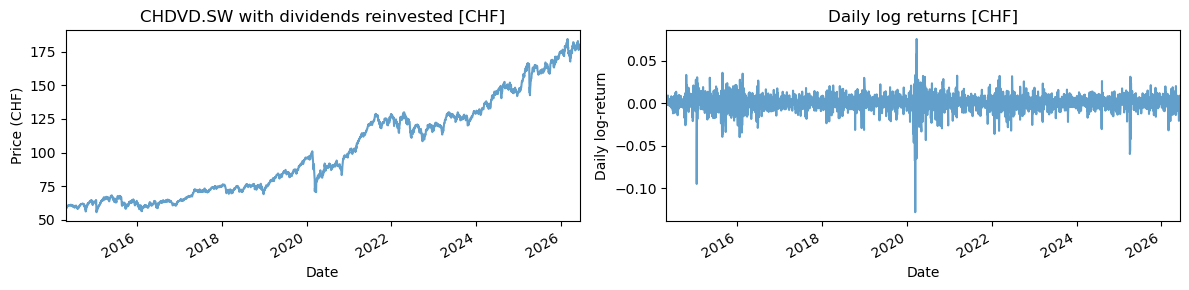

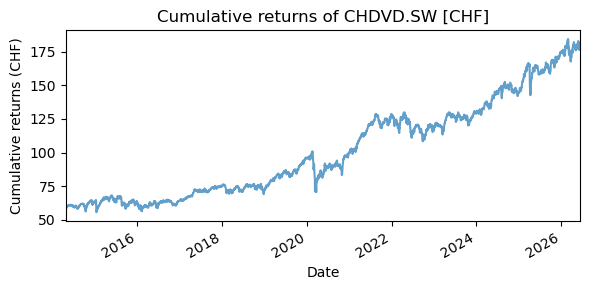

holdings loaded: 10 tickers  (0 with some NaN rows)


In [4]:
# Download data
if DOWNLOAD_DATA:
    print('Downloading data via extract_data.py ...')
    subprocess.run(['python', '../utils/extract_data.py'], check=True)
    print('Done.')

# Clean the data (impute missing values)
if CLEAN_DATA:
    print(f'Imputing missing values via clean_data.py (method={CLEAN_METHOD}) ...')
    subprocess.run(
        ['python', '../utils/clean_data.py', '--method', CLEAN_METHOD],
        check=True,
    )
    print('Done.')

#  Used the clean data if cleaned
if CLEAN_DATA:
    _panel = pd.read_csv(
        PROCESSED_DIR / 'close_panel_clean.csv', index_col=0, parse_dates=True
    ).sort_index()
    prices = validate_prices(_panel[cfg.benchmark].rename(cfg.benchmark))
else:
    prices = load_benchmark_close(cfg.benchmark)

# Compute log-returns
returns = log_returns(prices).rename('ret')
      

print(f'{cfg.benchmark}: {len(prices)} obs, '
      f'{prices.index.min().date()} -> {prices.index.max().date()}')

fig, ax = plt.subplots(1, 2, figsize=(12, 3))
prices.plot(ax=ax[0], title=f'{cfg.benchmark} with dividends reinvested [CHF]', alpha=0.7)
ax[0].set_ylabel('Price (CHF)')
returns.plot(ax=ax[1], title='Daily log returns [CHF]', alpha=0.7)
ax[1].set_ylabel('Daily log-return')
ax[0].margins(x=0); ax[1].margins(x=0)
plt.tight_layout(); plt.show()

# Sanity check: summing log returns and exponentiating to get cumulative returns, then multiplying by the initial price to get the cumulative price
cumulative_returns = np.exp(returns.cumsum()) * prices.iloc[0]
fig, ax = plt.subplots(figsize=(6, 3))
cumulative_returns.plot(ax=ax, title=f'Cumulative returns of {cfg.benchmark} [CHF]', alpha=0.7)
ax.set_ylabel('Cumulative returns (CHF)')
ax.margins(x=0)
plt.tight_layout(); plt.show()

# Load holdings prices (used for later features and signals)
_close_panel  = load_close_panel()
holding_prices = _close_panel[[c for c in cfg.holdings if c in _close_panel.columns]]
print(f'holdings loaded: {holding_prices.shape[1]} tickers  '
      f'({holding_prices.isna().any().sum()} with some NaN rows)')

## 2. Features & signals
Features (see make_features for info) and economically-motivated signal sets.

**Signals are computed from real historical prices and returns**: they show how
each strategy rule would have behaved on actual CHDVD.SW data. The plot below shows their
raw values over the **out-of-sample test period** so you can see their dynamics over a stock
before any model touches them.  

The right-hand column shows what position rule each value maps to (see `signals_to_positions()` in `utils/signals.py`).

In [5]:
from utils.features import make_features, feature_summary
from utils.signals import signal_metadata_table

# Compute features from prices, daily close-to-close returns, and holdings close panel.
# Features are in _ticker_rolling function in utils/features.py, and include:
# Per-ticker features: momentum, volatility, max drawdown, ...
feats = make_features(prices, returns, holding_prices, cfg.roll_windows, cfg.past_window)

# Signals set a over the benchmark
sig_a = signal_set_a(prices, returns)
sig_b = signal_set_b(prices, returns)
sig_c = signal_set_c(prices, returns)

# Feature matrix summary
print(f'Raw feature matrix: {len(feats.columns)} columns  '
      f'(holdings features will be compressed to PCA components in make_splits to reduec their big dimensionality)')
display(feature_summary(feats, cfg.benchmark))

# Signals summary 
print('\nSignals (raw values -> position rules {-1, 0, +1}):')
display(signal_metadata_table())
print('\nSample signal values -> last 5 days (i.e. rows) of the test period (last 5 days):')
signals_last_5_days = sig_a.join(sig_b).join(sig_c).dropna().tail()
display(signals_last_5_days)

# Display sign of signlas last 5 days
print('Signal positions (after applying sign rules on the signals i.e. what to do: long, hold, short) -> last 5 days of the test period:')
positions_last_5_days = signals_to_positions(signals_last_5_days, signals_last_5_days, signals_last_5_days)
display(positions_last_5_days)

Raw feature matrix: 506 columns  (holdings features will be compressed to PCA components in make_splits to reduec their big dimensionality)


,Group,Count,Col pattern,Description
0,Benchmark rolling,44,CHDVD_SW_{type}_{window},"pct_rank, vs_max/min/mean, vol, Sharpe, FFT ×..."
1,Holdings rolling,440,[ticker]_{type}_{window},same 9 features × each holding × roll_windows ...
2,Cross-sectional,2,xs_*,"xs_dispersion (holding ret std), xs_mean_corr_..."
3,Lagged returns,20,ret_lag_{k},trailing 20 daily log-returns of CHDVD.SW



Signals (raw values -> position rules {-1, 0, +1}):


,set,hyperparameters,position_rule
signal,,,
ma_cross_50_200,A,"fast_window=50, slow_window=200",sign(fast_SMA - slow_SMA)
mom_12_1,A,"lookback_days=252, skip_days=21",sign(price[-21] / price[-252] - 1)
trend_strength_20,A,window=20,"mean(sign(daily_ret)) ∈ [-1, 1] (continuous)"
rsi_14,B,"window=14, oversold_thr=30, overbought_thr=70","+1 if RSI < 30 (oversold), -1 if RSI > 70 (ove..."
bollinger_z_20,B,"window=20, lower_thr=-1, upper_thr=1","+1 if z < -1 (below band), -1 if z > 1 (above ..."
vol_ratio_20_100,B,"fast_window=20, slow_window=100, exit_thr=1.5","-1 (risk-off) if ratio > 1.5, else 0"
ret_autocorr_20,C,window=20,"sign(autocorr): +1=momentum regime, -1=mean-re..."
ret_skew_60,C,window=60,sign(skew): -1=crash-risk tail
vov_ratio_20_60,C,"fast_window=20, slow_window=60, flat_thr=1.2","0 (flat) if ratio > 1.2 (regime instability), ..."



Sample signal values -> last 5 days (i.e. rows) of the test period (last 5 days):


,ma_cross_50_200,mom_12_1,trend_strength_20,rsi_14,bollinger_z_20,vol_ratio_20_100,ret_autocorr_20,ret_skew_60,vov_ratio_20_60
Date,,,,,,,,,
2026-06-04,0.031877,0.080293,0.1,47.142843,-0.688478,0.978012,-0.113090,-0.078402,1.262766
2026-06-05,0.032602,0.078598,0.1,50.835621,-0.329456,0.841224,-0.112948,-0.129207,1.225806
2026-06-08,0.033307,0.101256,0.1,41.159820,-0.922535,0.789708,0.088084,-0.114916,1.149272
2026-06-09,0.033946,0.087983,0.2,41.654950,-0.311071,0.806557,-0.009926,-0.117288,1.031073
2026-06-10,0.034438,0.077693,0.2,46.938801,0.372157,0.829099,0.058485,-0.183362,0.948083


Signal positions (after applying sign rules on the signals i.e. what to do: long, hold, short) -> last 5 days of the test period:


,pos_ma_cross,pos_mom_12_1,pos_trend_20,pos_rsi,pos_bollinger,pos_vol_regime,pos_autocorr,pos_skew,pos_vov_stable
Date,,,,,,,,,
2026-06-04,1.0,1.0,1.0,0.0,0.0,0.0,-1.0,-1.0,0.0
2026-06-05,1.0,1.0,1.0,0.0,0.0,0.0,-1.0,-1.0,0.0
2026-06-08,1.0,1.0,1.0,0.0,0.0,0.0,1.0,-1.0,1.0
2026-06-09,1.0,1.0,1.0,0.0,0.0,0.0,-1.0,-1.0,1.0
2026-06-10,1.0,1.0,1.0,0.0,0.0,0.0,1.0,-1.0,1.0


## 3. Supervised dataset
Chronological (i.e. train on previous period) train/val/test split; the Ml models are trained on train only and validated on test.
We merge train + validate, so we have a train/test split.

**How signals become features:** `make_splits` creates the signals internally, and keeps them as a raw value.

**PCA on holding features:** the holdings tickers features are
highly correlated (same Swiss macro environment).  A joint StandardScaler -> PCA step
compresses them to `pca_n_components` components while retaining at least
`pca_variance_threshold` of cumulative variance.  Set `pca_all_features=True` to PCA
the entire feature matrix instead (i.e. also to CH.DVD)

  PCA on 442 holding features → 10 components  (84.6% variance explained  |  threshold=95%, max=10)
    PC 1: 33.701%  cumulative 33.701%
    PC 2: 13.695%  cumulative 47.396%
    PC 3: 11.500%  cumulative 58.896%
    PC 4: 9.078%  cumulative 67.974%
    PC 5: 4.429%  cumulative 72.403%
    PC 6: 3.503%  cumulative 75.907%
    PC 7: 3.171%  cumulative 79.077%
    PC 8: 2.310%  cumulative 81.388%
    PC 9: 1.691%  cumulative 83.079%
    PC10: 1.550%  cumulative 84.629%

Features after PCA: 83
  benchmark + signal positions  : 73
  PCA components (holdings)     : 10

train / val / test: 1873 / 401 / 402  trading days
test window : 2024-10-23 → 2026-06-09


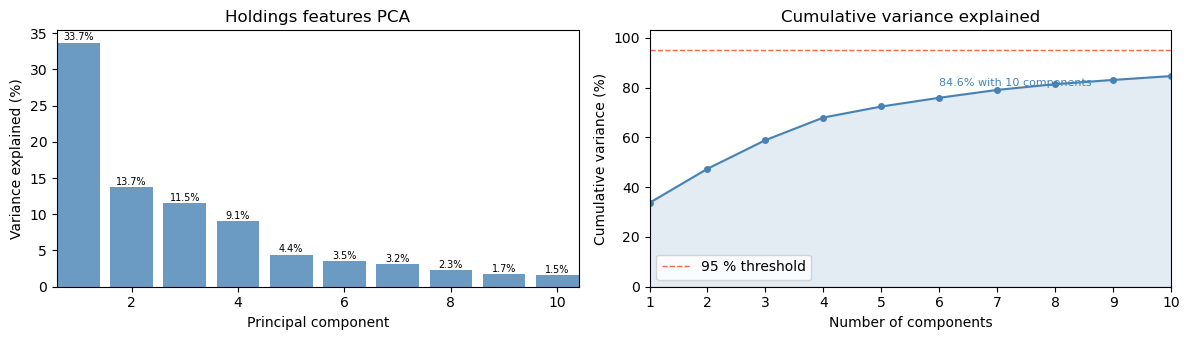

In [6]:
# Create our train/val/test splits, and apply PCA to the holdings features to reduce dimensionality
split = make_splits(prices, returns, cfg,
                    use_set_a=True, use_set_b=True, use_set_c=True,
                    holding_prices=holding_prices,
                    pca_n_components=PCA_N_COMPONENTS_FULL,
                    pca_variance_threshold=PCA_VARIANCE_THRESHOLD,
                    pca_all_features=False)

print(f'\nFeatures after PCA: {split.n_features}')
print(f'  benchmark + signal positions  : {len([f for f in split.feature_names if not f.startswith("pca_")])}')
print(f'  PCA components (holdings)     : {len([f for f in split.feature_names if f.startswith("pca_")])}')
print(f'\ntrain / val / test: {len(split.y_train)} / {len(split.y_val)} / {len(split.y_test)}  trading days')
print(f'test window : {split.dates_test.min().date()} → {split.dates_test.max().date()}')

# PCA  plot (shown if PCA was applied)
if split.pca_explained_var is not None:
    ev  = split.pca_explained_var * 100
    cum = np.cumsum(ev)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))

    ax1.bar(range(1, len(ev) + 1), ev, color='steelblue', alpha=0.8)
    ax1.set_xlabel('Principal component')
    ax1.set_ylabel('Variance explained (%)')
    ax1.set_title('Holdings features PCA')
    for i, v in enumerate(ev):
        if v > 1.0:
            ax1.text(i + 1, v + 0.3, f'{v:.1f}%', ha='center', fontsize=7)

    ax2.plot(range(1, len(cum) + 1), cum, marker='o', markersize=4, color='steelblue')
    ax2.axhline(95, color='tomato', linestyle='--', linewidth=1, label='95 % threshold')
    ax2.fill_between(range(1, len(cum) + 1), 0, cum, alpha=0.15, color='steelblue')
    ax2.set_xlabel('Number of components')
    ax2.set_ylabel('Cumulative variance (%)')
    ax2.set_title('Cumulative variance explained')
    ax2.set_ylim(0, 103)
    ax2.legend()
    ax2.text(len(cum) * 0.6, cum[-1] - 4,
             f'{cum[-1]:.1f}% with {len(ev)} components', fontsize=8, color='steelblue')

    plt.tight_layout()
    plt.show()

### Per-feature and signal Information Coefficient (on the test set)
IC = corr(feature_t, realized_return_{t+1}). 
Only features with IC != 0 are potentially true indicators; the rest carry no individual predictive information
(the model may still combine them usefully, but each alone is noise).

IC is scale-invariant, so it can be computed directly on the standardised `split.X_test`.

['CHDVD_SW_pct_rank_50', 'CHDVD_SW_vs_max_50', 'CHDVD_SW_vs_min_50', 'CHDVD_SW_vs_mean_50', 'CHDVD_SW_vol_50', 'CHDVD_SW_sharpe_50', 'CHDVD_SW_fft_1_50', 'CHDVD_SW_fft_2_50', 'CHDVD_SW_fft_3_50', 'CHDVD_SW_fft_4_50', 'CHDVD_SW_fft_5_50', 'CHDVD_SW_pct_rank_200', 'CHDVD_SW_vs_max_200', 'CHDVD_SW_vs_min_200', 'CHDVD_SW_vs_mean_200', 'CHDVD_SW_vol_200', 'CHDVD_SW_sharpe_200', 'CHDVD_SW_fft_1_200', 'CHDVD_SW_fft_2_200', 'CHDVD_SW_fft_3_200', 'CHDVD_SW_fft_4_200', 'CHDVD_SW_fft_5_200', 'CHDVD_SW_pct_rank_365', 'CHDVD_SW_vs_max_365', 'CHDVD_SW_vs_min_365', 'CHDVD_SW_vs_mean_365', 'CHDVD_SW_vol_365', 'CHDVD_SW_sharpe_365', 'CHDVD_SW_fft_1_365', 'CHDVD_SW_fft_2_365', 'CHDVD_SW_fft_3_365', 'CHDVD_SW_fft_4_365', 'CHDVD_SW_fft_5_365', 'CHDVD_SW_pct_rank_global', 'CHDVD_SW_vs_max_global', 'CHDVD_SW_vs_min_global', 'CHDVD_SW_vs_mean_global', 'CHDVD_SW_vol_global', 'CHDVD_SW_sharpe_global', 'CHDVD_SW_fft_1_global', 'CHDVD_SW_fft_2_global', 'CHDVD_SW_fft_3_global', 'CHDVD_SW_fft_4_global', 'CHDVD_SW_

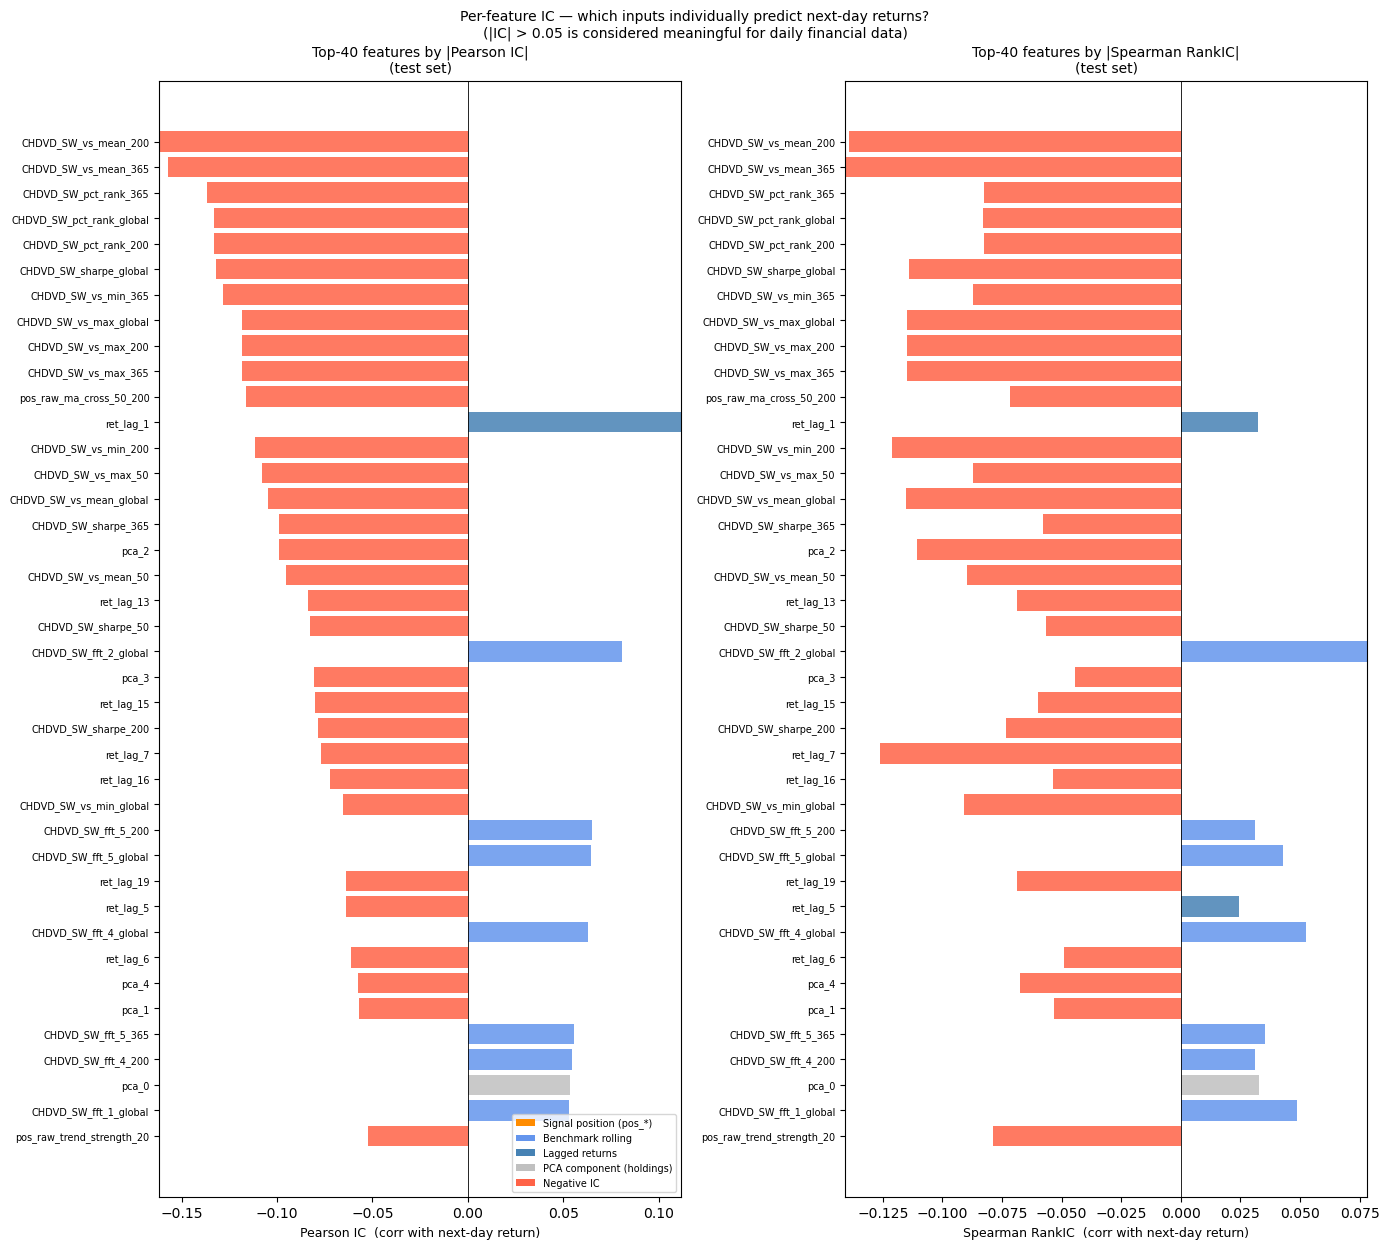

Feature-group IC summary (test set):


,mean_abs_IC,max_abs_IC,mean_abs_RankIC,n_features
group,,,,
Benchmark rolling,0.0711,0.1618,0.0592,44
Lagged returns,0.0457,0.1118,0.0493,20
Holdings PCA,0.0432,0.0991,0.0459,10
Signal positions,0.0376,0.1162,0.0427,9


In [7]:
from scipy.stats import spearmanr

_y = split.y_test                     
_X = split.X_test

# Features names and signlas name
_names = split.feature_names

print(_names)  
print(len(_names))

print(_X.shape)
print(len(split.feature_names))
ic_rows = []
for i, fname in enumerate(_names):
    x = _X[:, i]
    valid = np.isfinite(x) & np.isfinite(_y)
    if valid.sum() < 20:
        ic_rows.append({'feature': fname, 'IC': np.nan, 'RankIC': np.nan})
        continue
    ic      = np.corrcoef(x[valid], _y[valid])[0, 1]
    rank_ic = spearmanr(x[valid], _y[valid]).statistic
    ic_rows.append({'feature': fname, 'IC': ic, 'RankIC': rank_ic})

ic_df = pd.DataFrame(ic_rows).set_index('feature').dropna()
ic_df = ic_df.reindex(ic_df['IC'].abs().sort_values(ascending=False).index)

# Colour by feature group
def _feat_color(name):
    if name.startswith('pos_'):    return 'darkorange'   # signal positions
    if name.startswith('pca_'):    return 'silver'        # PCA (holding features)
    if name.startswith('ret_lag'): return 'steelblue'    # lagged returns
    return 'cornflowerblue'                               # benchmark rolling

_colors = [_feat_color(n) for n in ic_df.index]

# Plot: top-40 features by |IC|
top = ic_df.head(40)
top_colors = _colors[:40]

fig, axes = plt.subplots(1, 2, figsize=(14, max(6, len(top) * 0.28 + 1.5)))
for ax, metric, title in [
    (axes[0], 'IC',     'Pearson IC'),
    (axes[1], 'RankIC', 'Spearman RankIC'),
]:
    vals = top[metric]
    bar_colors = ['tomato' if v < 0 else c for v, c in zip(vals, top_colors)]
    ax.barh(top.index[::-1], vals.values[::-1], color=bar_colors[::-1], alpha=0.85)
    ax.axvline(0, color='k', linewidth=0.6)
    ax.set_xlabel(f'{title}  (corr with next-day return)', fontsize=9)
    ax.set_title(f'Top-{len(top)} features by |{title}|\n(test set)', fontsize=10)
    ax.tick_params(axis='y', labelsize=7)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='darkorange', label='Signal position (pos_*)'),
    Patch(facecolor='cornflowerblue', label='Benchmark rolling'),
    Patch(facecolor='steelblue', label='Lagged returns'),
    Patch(facecolor='silver', label='PCA component (holdings)'),
    Patch(facecolor='tomato', label='Negative IC'),
]
axes[0].legend(handles=legend_elements, fontsize=7, loc='lower right')
fig.suptitle('Per-feature IC — which inputs individually predict next-day returns?\n'
             '(|IC| > 0.05 is considered meaningful for daily financial data)',
             fontsize=10)
plt.tight_layout()
plt.show()

# Summary by group
def _group(name):
    if name.startswith('pos_'):    return 'Signal positions'
    if name.startswith('pca_'):    return 'Holdings PCA'
    if name.startswith('ret_lag'): return 'Lagged returns'
    return 'Benchmark rolling'

ic_df['group'] = [_group(n) for n in ic_df.index]
summary = ic_df.groupby('group')[['IC', 'RankIC']].agg(
    mean_abs_IC=('IC', lambda x: x.abs().mean()),
    max_abs_IC=('IC', lambda x: x.abs().max()),
    mean_abs_RankIC=('RankIC', lambda x: x.abs().mean()),
    n_features=('IC', 'count'),
).sort_values('mean_abs_IC', ascending=False)
print("Feature-group IC summary (test set):")
display(summary.style.format('{:.4f}', subset=['mean_abs_IC','max_abs_IC','mean_abs_RankIC']))

### Signal strategies over the test period
Cumulative log-return of each position rule applied independently to the test set, vs Buy & Hold.

The idea is to show how they would behave individually in the trading strategy with their position the CH.DWD. 

Position 1 means long, you buy it at the beginning of the day, wait for it to go up and sell it.\
Position 0 means flat, you don't buy or sell anything, you keep the money. \
Position -1 means you short, sell the asset at the beginning of the day, buy it immediately the day after. \

            pos_ma_cross  pos_mom_12_1  pos_trend_20  pos_rsi  pos_bollinger  \
Date                                                                           
2026-06-03           1.0           1.0           1.0      0.0            1.0   
2026-06-04           1.0           1.0           1.0      0.0            0.0   
2026-06-05           1.0           1.0           1.0      0.0            0.0   
2026-06-08           1.0           1.0           1.0      0.0            0.0   
2026-06-09           1.0           1.0           1.0      0.0            0.0   

            pos_vol_regime  pos_autocorr  pos_skew  pos_vov_stable  
Date                                                                
2026-06-03             0.0          -1.0      -1.0             1.0  
2026-06-04             0.0          -1.0      -1.0             0.0  
2026-06-05             0.0          -1.0      -1.0             0.0  
2026-06-08             0.0           1.0      -1.0             1.0  
2026-06-09             0.

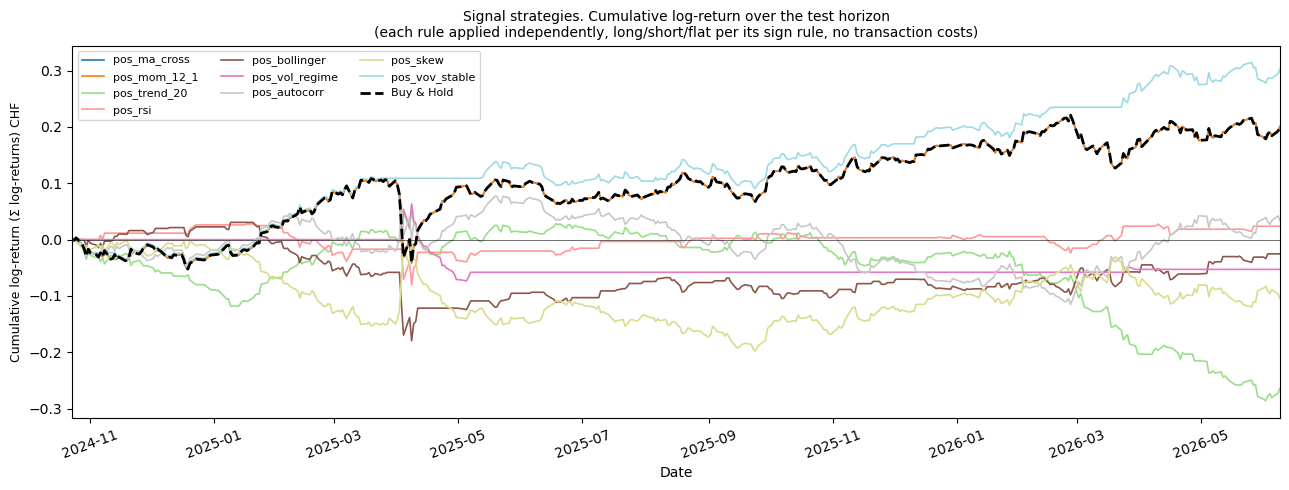

In [8]:
_sig_pos_plot = signals_to_positions(sig_a=sig_a, sig_b=sig_b, sig_c=sig_c).reindex(split.dates_test)

print(_sig_pos_plot.tail())
_real_test_plot = split.inverse_y(split.y_test)
_bh_cum = np.cumsum(_real_test_plot)

fig, ax = plt.subplots(figsize=(13, 5))

colors = plt.cm.tab20(np.linspace(0, 1, len(_sig_pos_plot.columns)))
for j, col in enumerate(_sig_pos_plot.columns):
    pos = _sig_pos_plot[col].fillna(0).values
    pnl = pos * _real_test_plot
    ax.plot(split.dates_test, np.cumsum(pnl), linewidth=1.2,
            color=colors[j], label=col)

ax.plot(split.dates_test, _bh_cum, 'k--', linewidth=2.0, label='Buy & Hold', zorder=5)
ax.axhline(0, color='k', linewidth=0.4)
ax.set_ylabel('Cumulative log-return (Σ log-returns) CHF', fontsize=9)
ax.set_xlabel('Date')
ax.set_title('Signal strategies. Cumulative log-return over the test horizon\n'
             '(each rule applied independently, long/short/flat per its sign rule, no transaction costs)',
             fontsize=10)
ax.legend(fontsize=8, ncol=3, loc='upper left')
ax.tick_params(axis='x', rotation=20)
ax.margins(x=0)
plt.tight_layout()
plt.show()

## 4. Experiment runner
Train a model, forecast in- and out-of-sample, report IC + test the annual return on
out-of-sample forecast against buy-and-hold.

### Masked-VAE: architecture & regularization detail

**Input.** The feature vector `x ∈ R^F` is augmented with the target return as one extra
slot (`F+1` total), plus a binary mask channel (1 = hidden). The target slot is **always
masked**; during training each feature is additionally masked with probability `mask_prob`.
Masked values are set to 0 (the standardised mean).

**Encoder** (two variants, `use_attention`):
- *MLP*: `[2·(F+1)] → hidden_dims` (e.g. 128 → 64), each block `Linear → LayerNorm → ReLU →
  Dropout`; two heads `fc_mu`, `fc_logvar` map to the latent (8–64 dims).
- *Transformer*: each `(value, mask)` pair is embedded as a token (`d_model=32`), passed
  through 2 `TransformerEncoder` layers (4 heads, FF 64, dropout), mean-pooled over tokens.

**Latent & decoder.** Reparameterisation `z = μ + σ·ε`; the MLP decoder mirrors the encoder
back to `F+1` outputs. The reconstruction of the always-masked target slot **is the forecast**.

**Loss.** Weighted reconstruction MSE (target slot up-weighted ×5) + `β · KL(N(μ,σ) ‖ N(0,I))`.

**Regularization used here:** β-VAE KL bottleneck (limits latent information), random input
masking (denoising objective — the model cannot rely on any single feature), dropout,
LayerNorm, L2 weight decay in Adam, early stopping on validation loss, and small latent
dimensions. The baselines are regularised too: Lasso via its L1 penalty (α by time-series
CV), XGBoost via subsampling, `reg_lambda` and early stopping.

**What else could be done:** larger β / smaller latent for a tighter bottleneck, input
noise or mixup augmentation, seed-ensembling of forecasts, LR scheduling/warm-up, early
stopping on validation IC instead of loss, and bagging over time blocks.

In [9]:
def _weights_path(name: str, horizon: int = 1) -> str:
    safe = name.replace(' ', '_').replace('(', '').replace(')', '')
    return f"{WEIGHTS_DIR}/{safe}_h{horizon}.pt"

def make_model(name: str, n_features: int, cfg_h):
    """Instantiate a fresh model by display name. To add a new model family, add a branch here."""
    if name == 'Linear':   return LinearBaseline()
    if name == 'XGBoost':  return XGBoostBaseline(cfg_h.xgb, seed=cfg_h.seed)
    key = VAE_KEY_MAP.get(name)
    if key is None:
        raise ValueError(f"Unknown model '{name}'. Add it to VAE_KEY_MAP or make_model().")
    return MaskedVAE(n_features, VAE_CONFIGS[key], seed=cfg_h.seed)

def _append_pred_rows(pred_rows, preds, sp, name, sig_label, h, pos_mode='long', cost_bps=0.0):
    pred_raw  = preds['test'].reindex(sp.dates_test).values
    positions = forecast_to_position(pred_raw, mode=pos_mode, cost_bps=cost_bps)
    realized  = sp.inverse_y(sp.y_test)
    pred_sc   = sp.y_scaler.transform(pred_raw.reshape(-1, 1)).ravel()
    for d, ps, pr, rr, p in zip(sp.dates_test, pred_sc, pred_raw, realized, positions):
        pred_rows.append({'date': d, 'horizon': h, 'model': name,
                          'signal_config': sig_label,
                          'pred_return_scaled': ps, 'pred_return_raw': pr,
                          'realized_return': rr, 'position': p})

def run_model(model_factory, split, name='model', train=True,
              position_mode='sign', cost_bps=1.0, verbose=False,
              seed=42, signals_meta=None, horizon=1):
    """Train on train+val combined; use test set for early-stop / loss monitoring only.

    train set : X_train + X_val  (maximise in-sample data)
    eval set  : X_test           (early stopping only — not used to select features/hyperparams)
    """
    wpath = _weights_path(name, horizon)

    X_tv = np.concatenate([split.X_train, split.X_val])
    y_tv = np.concatenate([split.y_train, split.y_val])

    if not train and os.path.exists(wpath):
        if name == 'Linear':       cls = LinearBaseline
        elif name == 'XGBoost':    cls = XGBoostBaseline
        elif name in VAE_KEY_MAP:  cls = MaskedVAE
        else:
            raise ValueError(f"No loader for model '{name}'")
        if verbose:
            print(f'  Loading pretrained weights from {wpath}')
        model = cls.load(wpath)
    else:
        model = model_factory()
        if verbose:
            print(f'  Train: {len(X_tv)} days (train+val)  |  '
                  f'eval/early-stop: {len(split.X_test)} days (test)')
        model.fit(X_tv, y_tv, split.X_test, split.y_test, verbose=verbose)
        model.save(wpath)
        if verbose:
            print(f'  Weights saved to {wpath}')

    pred_in  = split.inverse_y(model.predict(X_tv))
    pred_out = split.inverse_y(model.predict(split.X_test))
    real_in  = split.inverse_y(y_tv)
    real_out = split.inverse_y(split.y_test)

    curves, bt = backtest_table(pred_out, real_out, split.dates_test, position_mode, cost_bps,
                                horizon=horizon)
    res = {
        'IC_in':         information_coefficient(pred_in,  real_in),
        'IC_out':        information_coefficient(pred_out, real_out),
        'RankIC_out':    information_coefficient(pred_out, real_out, 'spearman'),
        'Sharpe_out':    bt['strat_Sharpe'],
        'AnnRet_out':    bt['strat_AnnReturn'],
        'position_mode': position_mode,
        'cost_bps':      cost_bps,
    }

    rpath = save_run(name, res, split, seed=seed,
                     signals_meta=signals_meta, weights_path=wpath,
                     position_mode=position_mode, cost_bps=cost_bps,
                     horizon=horizon)
    if verbose:
        print(f'  Results saved to {rpath}')

    dates_tv = np.concatenate([split.dates_train, split.dates_val])
    preds = {
        'train': pd.Series(pred_in,  index=dates_tv),
        'test':  pd.Series(pred_out, index=split.dates_test),
    }
    return res, curves, preds

# Oracle and B&H: daily strategy 
# Both are computed from daily log returns over the same calendar period as
# the primary-horizon test set. This gives a consistent ceiling regardless of
# which model horizon is being evaluated.
_test_start, _test_end = split.dates_test[0], split.dates_test[-1]
_daily_ret   = returns.loc[_test_start:_test_end]
_daily_arr   = _daily_ret.values
_daily_dates = _daily_ret.index

bench_stats  = backtest_table(np.zeros(len(_daily_arr)), _daily_arr, _daily_dates)[1]
oracle_curves, oracle_stats = backtest_table(_daily_arr, _daily_arr, _daily_dates)

print("Benchmarks (daily, test period):")
print(f"  Buy & Hold  Sharpe={bench_stats['bench_Sharpe']:+.3f}  "
      f"AnnRet={bench_stats['bench_AnnReturn']:+.2%} p.a.")
print(f"  Oracle L/S  Sharpe={oracle_stats['strat_Sharpe']:+.3f}  "
      f"AnnRet={oracle_stats['strat_AnnReturn']:+.2%} p.a.  "
      f"(perfect daily foresight — theoretical ceiling)")

Benchmarks (daily, test period):
  Buy & Hold  Sharpe=+0.789  AnnRet=+11.11% p.a.
  Oracle L/S  Sharpe=+14.993  AnnRet=+153.70% p.a.  (perfect daily foresight — theoretical ceiling)


### Train all models per family
On all the combinations of signals passed to it and features to it (4 comb)
On different horizons (i.e. predictions per day, every 5 day, ...). This results in one position per horizon.

**Hypothesis (horizons):** multi-day returns aggregate away daily noise, so IC_out
should increase with horizon (h=30 > h=1) while daily h=1 stays hardest; Sharpe need
not follow, since fewer rebalances also mean fewer independent bets.

In [10]:
import pathlib as _pl

_RESULTS_DIR = _pl.Path('../results')
_RESULTS_DIR.mkdir(exist_ok=True)

results, curves_by_model, preds_by_model = {}, {}, {}
results_all, curves_all, preds_all = {}, {}, {}  # keyed by (name, h, signals)
vae_rows, ablation_rows, full_signal_rows, pred_rows = [], [], [], []
_pos_mode = POSITION_MODE
_cost = COST_BPS

# For all horizons
for _h in HORIZONS:
    print(f"\n{'═'*60}")
    print(f"  HORIZON = {_h} day{'s' if _h > 1 else ''}")
    print(f"{'═'*60}")

    _cfg_h = dataclasses.replace(cfg, horizon=_h)
    split_h = split if _h == cfg.horizon else make_splits(
        prices, returns, _cfg_h,
        use_set_a=True, use_set_b=True, use_set_c=True,
        holding_prices=holding_prices,
        pca_n_components=PCA_N_COMPONENTS_FULL, pca_variance_threshold=PCA_VARIANCE_THRESHOLD,
    )

    # Full-signal models   
    _all_model_names = [m for ms in MODEL_FAMILIES.values() for m in ms]
    print(f"  Full-signal run: {len(_all_model_names)} models × A + B + C  (h={_h})")
    for name in _all_model_names:
        set_seed(_cfg_h.seed)
        res, curves, preds = run_model(
            lambda n=name, sp=split_h: make_model(n, sp.n_features, _cfg_h),
            split_h, name=name, train=TRAIN, verbose=VERBOSE,
            position_mode=_pos_mode, cost_bps=_cost,
            seed=_cfg_h.seed,
            signals_meta={'use_set_a': True, 'use_set_b': True, 'use_set_c': True},
            horizon=_h,
        )
        results_all[(name, _h, 'A + B + C')] = res
        curves_all[(name, _h, 'A + B + C')]  = curves
        preds_all[(name, _h, 'A + B + C')]   = preds
        if _h == cfg.horizon:
            results[name] = res; curves_by_model[name] = curves; preds_by_model[name] = preds

        if name in VAE_KEY_MAP and _h == cfg.horizon:
            vcfg = VAE_CONFIGS[VAE_KEY_MAP[name]]
            _tmp = MaskedVAE(split_h.n_features, vcfg)
            enc_p = sum(p.numel() for p in _tmp.encoder.parameters())
            dec_p = sum(p.numel() for p in _tmp.decoder.parameters())
            vae_rows.append({'variant': name, 'attention': vcfg.use_attention,
                             'enc_params': enc_p, 'total_params': enc_p + dec_p,
                             'IC_out': res['IC_out'], 'Sharpe_out': res['Sharpe_out']})

        full_signal_rows.append({'horizon': _h, 'model': name, 'signals': 'A + B + C',
                                  'IC_in': res['IC_in'], 'IC_out': res['IC_out'],
                                  'RankIC_out': res['RankIC_out'],
                                  'Sharpe_out': res['Sharpe_out'], 'AnnRet_out': res['AnnRet_out']})
        _append_pred_rows(pred_rows, preds, split_h, name, 'A + B + C', _h, _pos_mode, _cost)
        print(f"    {name:<22}  IC_out={res['IC_out']:+.4f}  RankIC={res['RankIC_out']:+.4f}  "
              f"Sharpe={res['Sharpe_out']:+.2f}  AnnRet={res['AnnRet_out']:+.2%}")

    # Signal ablation
    print(f"\n  Signal ablation: {len(ABLATION_MODELS)} models × {len(SIGNAL_CONFIGS)} configs  (h={_h})")
    for sname, scfg in SIGNAL_CONFIGS.items():
        sp = make_splits(prices, returns, _cfg_h, **scfg, holding_prices=holding_prices,
                         pca_n_components=PCA_N_COMPONENTS_ABLATION,
                         pca_variance_threshold=PCA_VARIANCE_THRESHOLD)
        for mname in ABLATION_MODELS:
            set_seed(_cfg_h.seed)
            wname = f'abl_h{_h}_{sname.replace(" ","_").replace("+","p")}_{mname}'
            res_ab, curves_ab, preds_ab = run_model(
                lambda n=mname, s=sp: make_model(n, s.n_features, _cfg_h),
                sp, name=wname, train=TRAIN, verbose=False,
                position_mode=_pos_mode, cost_bps=_cost,
                seed=_cfg_h.seed, signals_meta=scfg, horizon=_h,
            )
            results_all[(mname, _h, sname)] = res_ab
            curves_all[(mname, _h, sname)]  = curves_ab
            preds_all[(mname, _h, sname)]   = preds_ab
            ablation_rows.append({'horizon': _h, 'signals': sname, 'model': mname,
                                   'IC_in': res_ab['IC_in'], 'IC_out': res_ab['IC_out'],
                                   'RankIC_out': res_ab['RankIC_out'],
                                   'Sharpe_out': res_ab['Sharpe_out'], 'AnnRet_out': res_ab['AnnRet_out']})
            _append_pred_rows(pred_rows, preds_ab, sp, mname, sname, _h, _pos_mode, _cost)
            print(f"    {mname:<14}  ×  {sname}")

ablation = pd.DataFrame(ablation_rows)

pred_df = pd.DataFrame(pred_rows)
pred_df.to_csv(_RESULTS_DIR / 'predictions_test.csv', index=False)
n_runs = pred_df[['model', 'signal_config', 'horizon']].drop_duplicates().shape[0]
print(f"\nTotal runs: {len(HORIZONS)} horizons × (10 full + 8×3 ablation) = {len(HORIZONS)*34} runs")
print(f"Saved {len(pred_df):,} rows → results/predictions_test.csv  ({n_runs} distinct model/config/horizon combos)")


════════════════════════════════════════════════════════════
  HORIZON = 1 day
════════════════════════════════════════════════════════════
  Full-signal run: 10 models × A + B + C  (h=1)
  Train: 2274 days (train+val)  |  eval/early-stop: 402 days (test)
  Architecture : Linear (Lasso, alpha via TimeSeriesSplit-5 CV)
  Features     : 83
  Loss         : MSE + α·||β||₁  (L1 regularisation)


/home/virgilio/lib/minconda3/envs/gibbon/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.767e-01, tolerance: 1.212e-01
  model = cd_fast.enet_coordinate_descent_gram(
/home/virgilio/lib/minconda3/envs/gibbon/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.472e-01, tolerance: 1.212e-01
  model = cd_fast.enet_coordinate_descent_gram(


  Selected α   : 0.197717
  Non-zero coef: 1 / 83
  Weights saved to ../data/weights/Linear_h1.pt
  Results saved to /home/virgilio/projects/ml_for_finance/results/2026-06-11_13-46-03_Linear_seed42.json
    Linear                  IC_out=+0.0536  RankIC=+0.0327  Sharpe=+0.90  AnnRet=+12.58%
  Train: 2274 days (train+val)  |  eval/early-stop: 402 days (test)
  Architecture : XGBoost (gradient-boosted trees)
  Features     : 83
  Config       : trees=300  depth=4  lr=0.05  subsample=0.8  λ=1.0
  Loss         : MSE (reg:squarederror)
[0]	validation_0-rmse:0.89094
[31]	validation_0-rmse:0.99463
  Weights saved to ../data/weights/XGBoost_h1.pt
  Results saved to /home/virgilio/projects/ml_for_finance/results/2026-06-11_13-46-03_XGBoost_seed42.json
    XGBoost                 IC_out=+0.0186  RankIC=-0.0487  Sharpe=+0.85  AnnRet=+11.96%
  Train: 2274 days (train+val)  |  eval/early-stop: 402 days (test)
  Architecture : MaskedVAE  encoder=MLP
  Features     : 83 input  +  1 target token  =  8

/home/virgilio/lib/minconda3/envs/gibbon/lib/python3.13/site-packages/xgboost/sklearn.py:1116: UserWarning: [13:46:03] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)


  Epoch    1/100 | train_loss=5.3126 [MSE, scaled] | val_loss=0.8327 [MSE, scaled]
  Epoch   10/100 | train_loss=3.9133 [MSE, scaled] | val_loss=0.7978 [MSE, scaled]
  Epoch   20/100 | train_loss=3.2976 [MSE, scaled] | val_loss=0.7927 [MSE, scaled]
  Early stop at epoch 24/100 (best val_loss=0.7879 [MSE, scaled])
  Restored best weights (val_loss=0.7879)
  Weights saved to ../data/weights/VAE-tiny_h1.pt
  Results saved to /home/virgilio/projects/ml_for_finance/results/2026-06-11_13-46-06_VAE-tiny_seed42.json
    VAE-tiny                IC_out=+0.0714  RankIC=+0.0783  Sharpe=+0.90  AnnRet=+12.58%
  Train: 2274 days (train+val)  |  eval/early-stop: 402 days (test)
  Architecture : MaskedVAE  encoder=MLP
  Features     : 83 input  +  1 target token  =  84 aug dim
  Encoder      : hidden=(64, 32)  latent=16  params=14,144
  Decoder      : hidden=(32, 64)  params=8,308
  Total params : 22,452
  Loss         : MSE_recon (target_weight=5.0)  +  β=1.0 · KL
  Regularise   : mask_prob=0.3  dropo

...

  Subsampled every 30 days → 89 non-overlapping observations
  PCA on 442 holding features → 20 components  (94.0% variance explained  |  threshold=95%, max=20)
    PC 1: 33.355%  cumulative 33.355%
    PC 2: 15.229%  cumulative 48.584%
    PC 3: 11.381%  cumulative 59.965%
    PC 4: 8.271%  cumulative 68.237%
    PC 5: 4.791%  cumulative 73.027%
    PC 6: 3.708%  cumulative 76.736%
    PC 7: 3.431%  cumulative 80.167%
    PC 8: 2.482%  cumulative 82.649%
    PC 9: 1.727%  cumulative 84.376%
    PC10: 1.570%  cumulative 85.946%
    PC11: 1.324%  cumulative 87.270%
    PC12: 1.143%  cumulative 88.413%
    PC13: 1.070%  cumulative 89.483%
    PC14: 0.814%  cumulative 90.297%
    PC15: 0.765%  cumulative 91.062%
    PC16: 0.758%  cumulative 91.820%
    PC17: 0.651%  cumulative 92.471%
    PC18: 0.626%  cumulative 93.097%
    PC19: 0.500%  cumulative 93.596%
    PC20: 0.393%  cumulative 93.989%
    Linear          ×  A + B + C
    XGBoost         ×  A + B + C


/home/virgilio/lib/minconda3/envs/gibbon/lib/python3.13/site-packages/xgboost/sklearn.py:1116: UserWarning: [13:48:54] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)


    VAE-medium      ×  A + B + C
  Subsampled every 30 days → 89 non-overlapping observations
  PCA on 442 holding features → 20 components  (94.0% variance explained  |  threshold=95%, max=20)
    PC 1: 33.355%  cumulative 33.355%
    PC 2: 15.229%  cumulative 48.584%
    PC 3: 11.381%  cumulative 59.965%
    PC 4: 8.271%  cumulative 68.237%
    PC 5: 4.791%  cumulative 73.027%
    PC 6: 3.708%  cumulative 76.736%
    PC 7: 3.431%  cumulative 80.167%
    PC 8: 2.482%  cumulative 82.649%
    PC 9: 1.727%  cumulative 84.376%
    PC10: 1.570%  cumulative 85.946%
    PC11: 1.324%  cumulative 87.270%
    PC12: 1.143%  cumulative 88.413%
    PC13: 1.070%  cumulative 89.483%
    PC14: 0.814%  cumulative 90.297%
    PC15: 0.765%  cumulative 91.062%
    PC16: 0.758%  cumulative 91.820%
    PC17: 0.651%  cumulative 92.471%
    PC18: 0.626%  cumulative 93.097%
    PC19: 0.500%  cumulative 93.596%
    PC20: 0.393%  cumulative 93.989%


/home/virgilio/lib/minconda3/envs/gibbon/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.861e-03, tolerance: 4.437e-03
  model = cd_fast.enet_coordinate_descent(
/home/virgilio/lib/minconda3/envs/gibbon/lib/python3.13/site-packages/xgboost/sklearn.py:1116: UserWarning: [13:48:57] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)


    Linear          ×  No signals
    XGBoost         ×  No signals
    VAE-medium      ×  No signals

Total runs: 4 horizons × (10 full + 8×3 ablation) = 136 runs
Saved 17,816 rows → results/predictions_test.csv  (124 distinct model/config/horizon combos)


In [11]:
# Across all model families (i.e. Linear model, XGBoost, and all VAEs)
# print the best hoziron per model with the best compination 
_all_rows = pd.DataFrame(full_signal_rows + ablation_rows)

_best_per_family = {}
_model_meta = {m: (cfg.horizon, 'A + B + C') for ms in MODEL_FAMILIES.values() for m in ms}
for fam, models in MODEL_FAMILIES.items():
    subset = _all_rows[_all_rows['model'].isin(models)]
    if subset.empty:
        continue
    best_row = subset.loc[subset['AnnRet_out'].astype(float).idxmax()]
    m    = best_row['model']
    h    = int(best_row['horizon'])
    sigs = best_row['signals']
    _best_per_family[fam] = m
    _model_meta[m] = (h, sigs)
    key = (m, h, sigs)
    if key in results_all:
        results[m]         = results_all[key]
        curves_by_model[m] = curves_all[key]
        preds_by_model[m]  = preds_all[key]

_rep_models = list(_best_per_family.values())

def model_label(m):
    """'VAE-medium (H=15, F={A,B})' — horizon + signal sets used by this run."""
    h, s = _model_meta.get(m, (cfg.horizon, 'A + B + C'))
    return f"{m} (H={h}, F={{{s.replace(' only', '').replace(' + ', ',')}}})"

print("Best model per family (best AnnRet_out across all runs):")
for fam, m in _best_per_family.items():
    best = _all_rows[_all_rows['model'] == m].sort_values('AnnRet_out', ascending=False).iloc[0]
    print(f"  {fam:<10}  {m:<22}  h={int(best['horizon'])}  signals={best['signals']:<14}  "
          f"AnnRet={float(best['AnnRet_out']):+.2%}  IC_out={float(best['IC_out']):+.4f}")

print("B&H and Orcale and indiivudal signals:")
print(f"  Buy & Hold  Sharpe={bench_stats['bench_Sharpe']:+.3f}  "
      f"AnnRet={bench_stats['bench_AnnReturn']:+.2%} p.a.")
print(f"  Oracle L/S  Sharpe={oracle_stats['strat_Sharpe']:+.3f}  "
      f"AnnRet={oracle_stats['strat_AnnReturn']:+.2%} p.a.  "
      f"(perfect daily foresight — theoretical ceiling)")   


# Common evaluation window for cross-model plots: different horizons produce
# slightly different test windows, so clip every curve to the overlap and
# re-anchor cumulative returns at 0 there (see Definitions cell at the top).
COMMON_START = max(curves_by_model[m].index[0]  for m in _rep_models)
COMMON_END   = min(curves_by_model[m].index[-1] for m in _rep_models)

def align_curve(cum):
    """Clip a cumulative-log-return Series to [COMMON_START, COMMON_END], restart at 0."""
    s = cum.loc[COMMON_START:COMMON_END]
    return s - s.iloc[0]

print(f"\nCommon plot window: {COMMON_START.date()} → {COMMON_END.date()}  "
      f"(all strategies clipped to the overlap and evaluated from 0 there)")


Best model per family (best AnnRet_out across all runs):
  Linear      Linear                  h=1  signals=A + B + C       AnnRet=+12.58%  IC_out=+0.0536
  XGBoost     XGBoost                 h=5  signals=A + B           AnnRet=+28.60%  IC_out=+0.3248
  VAE-MLP     VAE-medium              h=1  signals=No signals      AnnRet=+25.95%  IC_out=+0.1408
  VAE-Attn    VAE-attn-medium         h=15  signals=A + B + C       AnnRet=+18.81%  IC_out=+0.5195
B&H and Orcale and indiivudal signals:
  Buy & Hold  Sharpe=+0.789  AnnRet=+11.11% p.a.
  Oracle L/S  Sharpe=+14.993  AnnRet=+153.70% p.a.  (perfect daily foresight — theoretical ceiling)

Common plot window: 2024-10-23 → 2026-05-08  (all strategies clipped to the overlap and evaluated from 0 there)


## 5. Model Comparison
 Full comparison: all 3×34 = 102 runs (3 horizons × 10 full-signal + 8×3 ablation) trained in §4.


 Sorted by annualised return descending. Oracle and Buy & Hold appended at bottom.


In [12]:
_bh_annret = float(bench_stats['bench_AnnReturn'])
# _pos_mode / _cost come from the big-run cell (section 4) — single source of truth

# ── Parameter counts + memory per model (size is horizon-independent) ─────
def _params_mem(name: str):
    """Returns (n_params: int|str, mem_mb: float)."""
    if name in VAE_KEY_MAP:
        vcfg = VAE_CONFIGS[VAE_KEY_MAP[name]]
        _tmp = MaskedVAE(split.n_features, vcfg)
        n = sum(p.numel() for p in list(_tmp.encoder.parameters())
                             + list(_tmp.decoder.parameters()))
        return n, n * 4 / 1e6
    elif name == 'Linear':
        n = split.n_features
        return n, n * 8 / 1e6
    elif name == 'XGBoost':
        _xp = _weights_path('XGBoost', cfg.horizon)
        mem = os.path.getsize(_xp) / 1e6 if os.path.exists(_xp) else float('nan')
        return f'~{cfg.xgb.n_estimators}×2^{cfg.xgb.max_depth} nodes', mem
    return '?', float('nan')

_pm = {name: _params_mem(name) for name in list(results.keys()) + ['Linear', 'XGBoost']}

# ── Build rows from full_signal_rows + ablation_rows ──────────────────────
_all_rows = []
for r in full_signal_rows:
    n_p, mem = _pm.get(r['model'], ('?', float('nan')))
    _all_rows.append({
        'Horizon': r['horizon'], 'Model': r['model'], 'Signals': r['signals'],
        'Cat': MODEL_CATEGORY.get(r['model'], '?'),
        'Params': n_p, 'Mem MB': round(mem, 3) if mem == mem else float('nan'),
        'IC_in': r['IC_in'], 'IC_out': r['IC_out'],
        'RankIC_out': r['RankIC_out'],
        'Sharpe': r['Sharpe_out'], 'AnnRet': r['AnnRet_out'],
        'vs_BH': np.expm1(float(r['AnnRet_out'])) - np.expm1(_bh_annret),
    })
for r in ablation_rows:
    n_p, mem = _pm.get(r['model'], ('?', float('nan')))
    _all_rows.append({
        'Horizon': r['horizon'], 'Model': r['model'], 'Signals': r['signals'],
        'Cat': MODEL_CATEGORY.get(r['model'], '?'),
        'Params': n_p, 'Mem MB': round(mem, 3) if mem == mem else float('nan'),
        'IC_in': r['IC_in'], 'IC_out': r['IC_out'],
        'RankIC_out': r['RankIC_out'],
        'Sharpe': r['Sharpe_out'], 'AnnRet': r['AnnRet_out'],
        'vs_BH': np.expm1(float(r['AnnRet_out'])) - np.expm1(_bh_annret),
    })

all_runs = pd.DataFrame(_all_rows).sort_values(['Horizon', 'AnnRet'], ascending=[True, False])

# ── Oracle + Buy & Hold (primary horizon) ────────────────────────────────
_ref = pd.DataFrame([
    {'Horizon': cfg.horizon, 'Model': '── Oracle', 'Signals': 'perfect foresight', 'Cat': '—',
     'Params': '—', 'Mem MB': '—',
     'IC_in': float('nan'), 'IC_out': 1.0, 'RankIC_out': 1.0,
     'Sharpe': oracle_stats['strat_Sharpe'],
     'AnnRet': oracle_stats['strat_AnnReturn'],
     'vs_BH': np.expm1(float(oracle_stats['strat_AnnReturn'])) - np.expm1(_bh_annret)},
    {'Horizon': cfg.horizon, 'Model': '── Buy & Hold', 'Signals': '(no model)', 'Cat': '—',
     'Params': '—', 'Mem MB': '—',
     'IC_in': float('nan'), 'IC_out': float('nan'), 'RankIC_out': float('nan'),
     'Sharpe': bench_stats['bench_Sharpe'],
     'AnnRet': _bh_annret, 'vs_BH': 0.0},
])
disp_raw = pd.concat([all_runs, _ref], ignore_index=True)

# ── Format ────────────────────────────────────────────────────────────────
disp = disp_raw.copy()
disp['Params'] = disp['Params'].map(lambda x: f'{x:,}' if isinstance(x, int) else str(x))
disp['Mem MB'] = disp['Mem MB'].map(lambda x: f'{x:.3f}' if isinstance(x, float) and x == x else str(x))
for col in ['IC_in', 'IC_out', 'RankIC_out']:
    disp[col] = disp[col].map(lambda x: f'{x:+.4f}' if isinstance(x, float) and x == x else '—')
disp['Sharpe'] = disp['Sharpe'].map(lambda x: f'{x:+.2f}' if isinstance(x, float) and x == x else '—')
disp['AnnRet'] = disp['AnnRet'].map(lambda x: f'{np.expm1(float(x)):+.2%}' if pd.notna(x) else '—')
disp['vs_BH']  = disp['vs_BH'].map(lambda x: f'{float(x):+.2%}' if pd.notna(x) else '—')

print(f"  {len(all_runs)} model runs  |  horizons={HORIZONS}  |  position_mode='{_pos_mode}'  |  cost={_cost} bps")
print("  Params = trainable weights (VAE/Linear) or node estimate (XGBoost)  |  Mem MB = float32/64 weights")
_cost_note = 'GROSS — no transaction costs (COST_BPS=0)' if _cost == 0 else f'net of {_cost:g} bps transaction costs'
print(f"  AnnRet / vs_BH = simple return [% p.a.] = exp(annualised log-return) − 1, {_cost_note}; B&H is always gross\n")
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    display(disp[['Horizon', 'Model', 'Signals', 'Cat', 'Params', 'Mem MB',
              'IC_in', 'IC_out', 'RankIC_out', 'Sharpe', 'AnnRet', 'vs_BH']])


  136 model runs  |  horizons=(1, 5, 15, 30)  |  position_mode='cost_aware'  |  cost=1.0 bps
  Params = trainable weights (VAE/Linear) or node estimate (XGBoost)  |  Mem MB = float32/64 weights
  AnnRet / vs_BH = simple return [% p.a.] = exp(annualised log-return) − 1, net of 1 bps transaction costs; B&H is always gross



,Horizon,Model,Signals,Cat,Params,Mem MB,IC_in,IC_out,RankIC_out,Sharpe,AnnRet,vs_BH
0,1,VAE-medium,No signals,VAE-MLP,"52,980",0.212,+0.0673,+0.1408,+0.1055,+1.86,+29.63%,+17.88%
1,1,VAE-medium,A + B + C,VAE-MLP,"52,980",0.212,+0.0203,+0.1341,+0.1174,+1.36,+20.96%,+9.21%
2,1,VAE-attn-small,A + B + C,VAE-Attn,"26,548",0.106,+0.0674,+0.0748,+0.0111,+1.23,+18.81%,+7.05%
3,1,VAE-medium,A + B + C,VAE-MLP,"52,980",0.212,+0.0359,+0.1177,+0.0821,+1.06,+15.95%,+4.20%
4,1,VAE-medium,A + C,VAE-MLP,"52,980",0.212,+0.0492,+0.0778,+0.1136,+1.03,+15.61%,+3.85%
5,1,VAE-small,A + B + C,VAE-MLP,"22,452",0.090,+0.0386,+0.2178,+0.1371,+1.03,+15.56%,+3.80%
6,1,XGBoost,A + B + C,XGBoost,~300×2^4 nodes,0.046,+0.2817,+0.0636,+0.0142,+1.03,+15.48%,+3.72%
7,1,VAE-medium,A only,VAE-MLP,"52,980",0.212,+0.0303,+0.1492,+0.0695,+0.96,+14.29%,+2.54%
8,1,VAE-medium,B only,VAE-MLP,"52,980",0.212,+0.0061,+0.1250,+0.0878,+0.90,+13.49%,+1.73%
9,1,Linear,A + B + C,Linear,83,0.001,+0.0532,+0.0536,+0.0327,+0.90,+13.41%,+1.66%


### Additonal plot on the test set data

### Pure-Signal Baselines
Each position from the different signals is tested **independently** as a
rule: `position ∈ {-1, 0, 1}`.

In [13]:
# Signal strategies: applied daily (they rebalance every day by design)
_daily_ret   = returns.loc[_test_start:_test_end]
_daily_arr   = _daily_ret.values
_daily_dates = _daily_ret.index

sig_pos = signals_to_positions(sig_a=sig_a, sig_b=sig_b, sig_c=sig_c)

_bh_ann = bench_stats['bench_AnnReturn']

sig_rows, sig_curves = [], {}
for col in sig_pos.columns:
    pos_test = sig_pos[col].reindex(_daily_dates).fillna(0).values
    curves_sig, bt = backtest_table(pos_test, _daily_arr, _daily_dates, mode='sign', cost_bps=_cost)
    sig_curves[col] = curves_sig['strategy']
    sig_rows.append({
        'rule':       col,
        'Sharpe':     bt['strat_Sharpe'],
        'AnnRet_%pa': np.expm1(bt['strat_AnnReturn']),
        'vs_BH_%pa':  np.expm1(bt['strat_AnnReturn']) - np.expm1(_bh_ann),
    })

combined = sig_pos.reindex(_daily_dates).fillna(0).mean(axis=1)
combined_pos = np.sign(combined)  # majority of long vs short votes; flat on ties
curves_comb, bt_comb = backtest_table(combined_pos, _daily_arr, _daily_dates, mode='sign', cost_bps=_cost)
sig_curves['── Combined (majority vote)'] = curves_comb['strategy']
sig_rows.append({'rule': '── Combined (majority vote)',
                 'Sharpe': bt_comb['strat_Sharpe'],
                 'AnnRet_%pa': np.expm1(bt_comb['strat_AnnReturn']),
                 'vs_BH_%pa': np.expm1(bt_comb['strat_AnnReturn']) - np.expm1(_bh_ann)})
sig_rows.append({'rule': '── Buy & Hold',
                 'Sharpe': bench_stats['bench_Sharpe'],
                 'AnnRet_%pa': np.expm1(_bh_ann), 'vs_BH_%pa': 0.0})

sig_baseline_df = pd.DataFrame(sig_rows).set_index('rule')
sig_baseline_df['AnnRet_%pa'] = sig_baseline_df['AnnRet_%pa'].map('{:+.2%}'.format)
sig_baseline_df['vs_BH_%pa']  = sig_baseline_df['vs_BH_%pa'].map('{:+.2%}'.format)
sig_baseline_df['Sharpe']     = sig_baseline_df['Sharpe'].map('{:+.3f}'.format)
print(f"Pure-signal baselines (long/short/flat per sign rule, daily rebalancing, test period):")
_cost_note = 'GROSS — no transaction costs (COST_BPS=0)' if _cost == 0 else f'net of {_cost:g} bps costs'
print(f"AnnRet / vs_BH = simple return [% p.a.] = exp(annualised log-return) − 1, {_cost_note}; B&H always gross")
display(sig_baseline_df)

Pure-signal baselines (long/short/flat per sign rule, daily rebalancing, test period):
AnnRet / vs_BH = simple return [% p.a.] = exp(annualised log-return) − 1, net of 1 bps costs; B&H always gross


,Sharpe,AnnRet_%pa,vs_BH_%pa
rule,,,
pos_ma_cross,+0.789,+11.75%,-0.01%
pos_mom_12_1,+0.789,+11.75%,-0.01%
pos_trend_20,+1.311,+18.67%,+6.92%
pos_rsi,-2.419,-20.53%,-32.29%
pos_bollinger,-5.264,-45.62%,-57.38%
pos_vol_regime,-0.213,-1.85%,-13.60%
pos_autocorr,-0.635,-8.56%,-20.31%
pos_skew,-0.168,-2.34%,-14.09%
pos_vov_stable,+1.743,+18.81%,+7.06%


Top-3 (family-best) by RankIC_out: [('VAE-attn-medium', '+0.3748'), ('XGBoost', '+0.1808'), ('VAE-medium', '+0.1055')]
Top-3 (family-best) by AnnRet_out: [('XGBoost', '+28.60%'), ('VAE-medium', '+25.95%'), ('VAE-attn-medium', '+18.81%')]


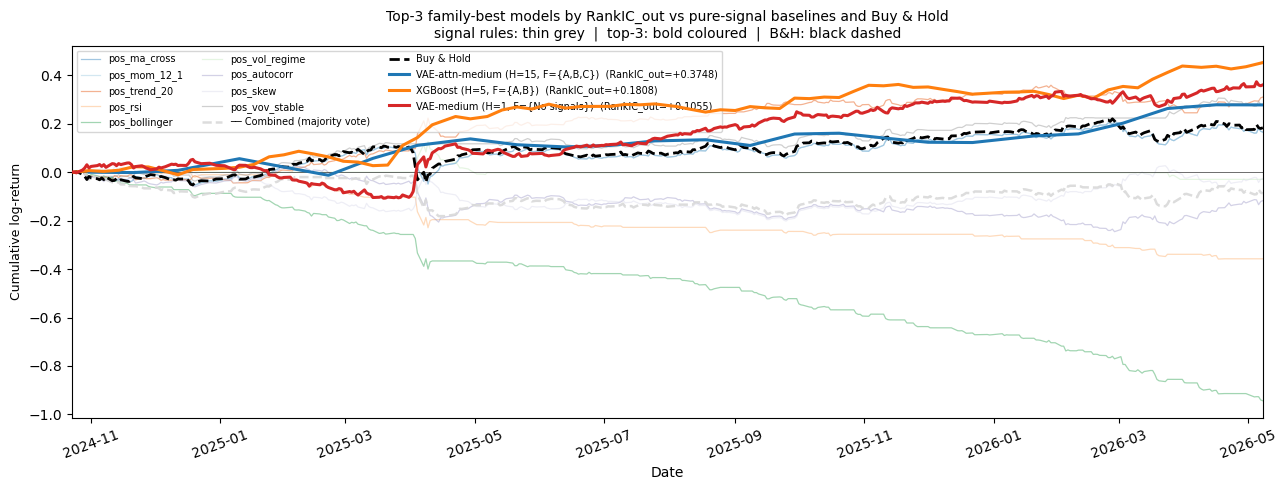

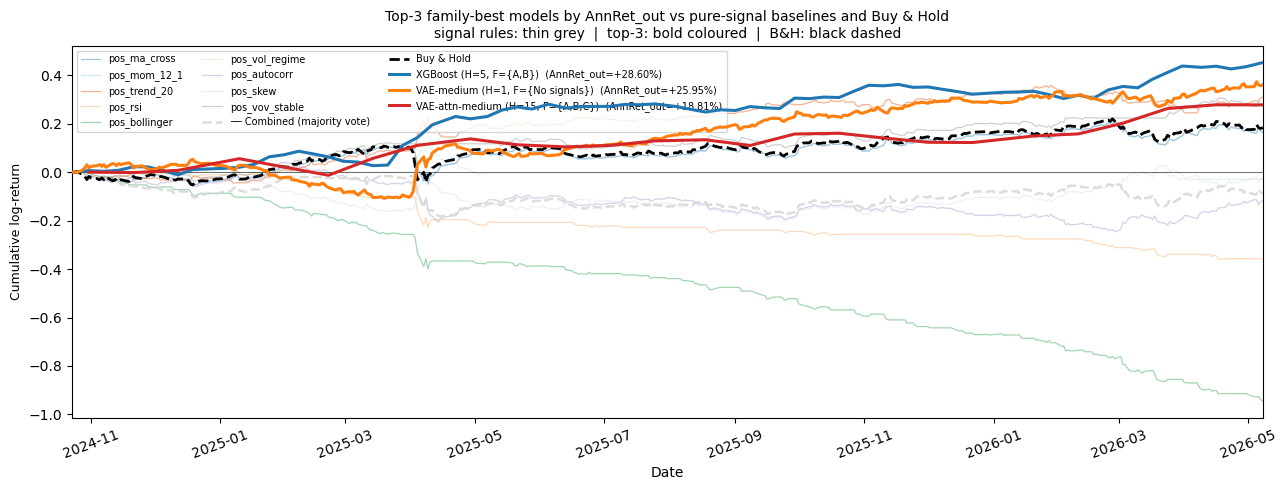

In [14]:
# Top models per family: ranked by RankIC_out and by AnnRet_out
_rank_ic_val = {m: results[m]['RankIC_out'] for m in _rep_models if pd.notna(results[m].get('RankIC_out'))}
_annret_val  = {m: results[m]['AnnRet_out'] for m in _rep_models if pd.notna(results[m].get('AnnRet_out'))}

_top3_ic = sorted(_rank_ic_val, key=_rank_ic_val.get, reverse=True)[:3]
_top3_ar = sorted(_annret_val,  key=_annret_val.get,  reverse=True)[:3]

print("Top-3 (family-best) by RankIC_out:", [(m, f'{_rank_ic_val[m]:+.4f}') for m in _top3_ic])
print("Top-3 (family-best) by AnnRet_out:", [(m, f'{float(_annret_val[m]):+.2%}') for m in _top3_ar])

_grey = plt.cm.tab20c(np.linspace(0, 1, len(sig_curves)))
_bh_s = align_curve(list(curves_by_model.values())[0]['buy_and_hold'])
_model_colors = ['tab:blue', 'tab:orange', 'tab:red']

for _top3, _vals, _metric_label, _fmt in [
    (_top3_ic, _rank_ic_val, 'RankIC_out', lambda v: f'{v:+.4f}'),
    (_top3_ar, _annret_val,  'AnnRet_out', lambda v: f'{float(v):+.2%}'),
]:
    fig, ax = plt.subplots(figsize=(13, 5))
    for j, (rule, cum) in enumerate(sig_curves.items()):
        cum  = align_curve(cum)
        lw   = 1.8 if 'Combined' in rule else 0.9
        ls   = '--' if 'Combined' in rule else '-'
        alph = 0.9 if 'Combined' in rule else 0.45
        ax.plot(cum.index, cum.values, color=_grey[j], linewidth=lw,
                linestyle=ls, alpha=alph, label=rule)
    ax.plot(_bh_s.index, _bh_s.values, 'k--', linewidth=2.0, label='Buy & Hold', zorder=5)
    for mname, col in zip(_top3, _model_colors):
        strat = align_curve(curves_by_model[mname]['strategy'])
        ax.plot(strat.index, strat.values, color=col, linewidth=2.2, zorder=6,
                label=f'{model_label(mname)}  ({_metric_label}={_fmt(_vals[mname])})')
    ax.axhline(0, color='k', linewidth=0.4)
    ax.set_ylabel('Cumulative log-return', fontsize=9)
    ax.set_xlabel('Date')
    ax.set_title(f'Top-3 family-best models by {_metric_label} vs pure-signal baselines and Buy & Hold\n'
                 'signal rules: thin grey  |  top-3: bold coloured  |  B&H: black dashed', fontsize=10)
    ax.legend(fontsize=7, ncol=3, loc='upper left')
    ax.tick_params(axis='x', rotation=20)
    ax.margins(x=0)
    plt.tight_layout()
    plt.show()


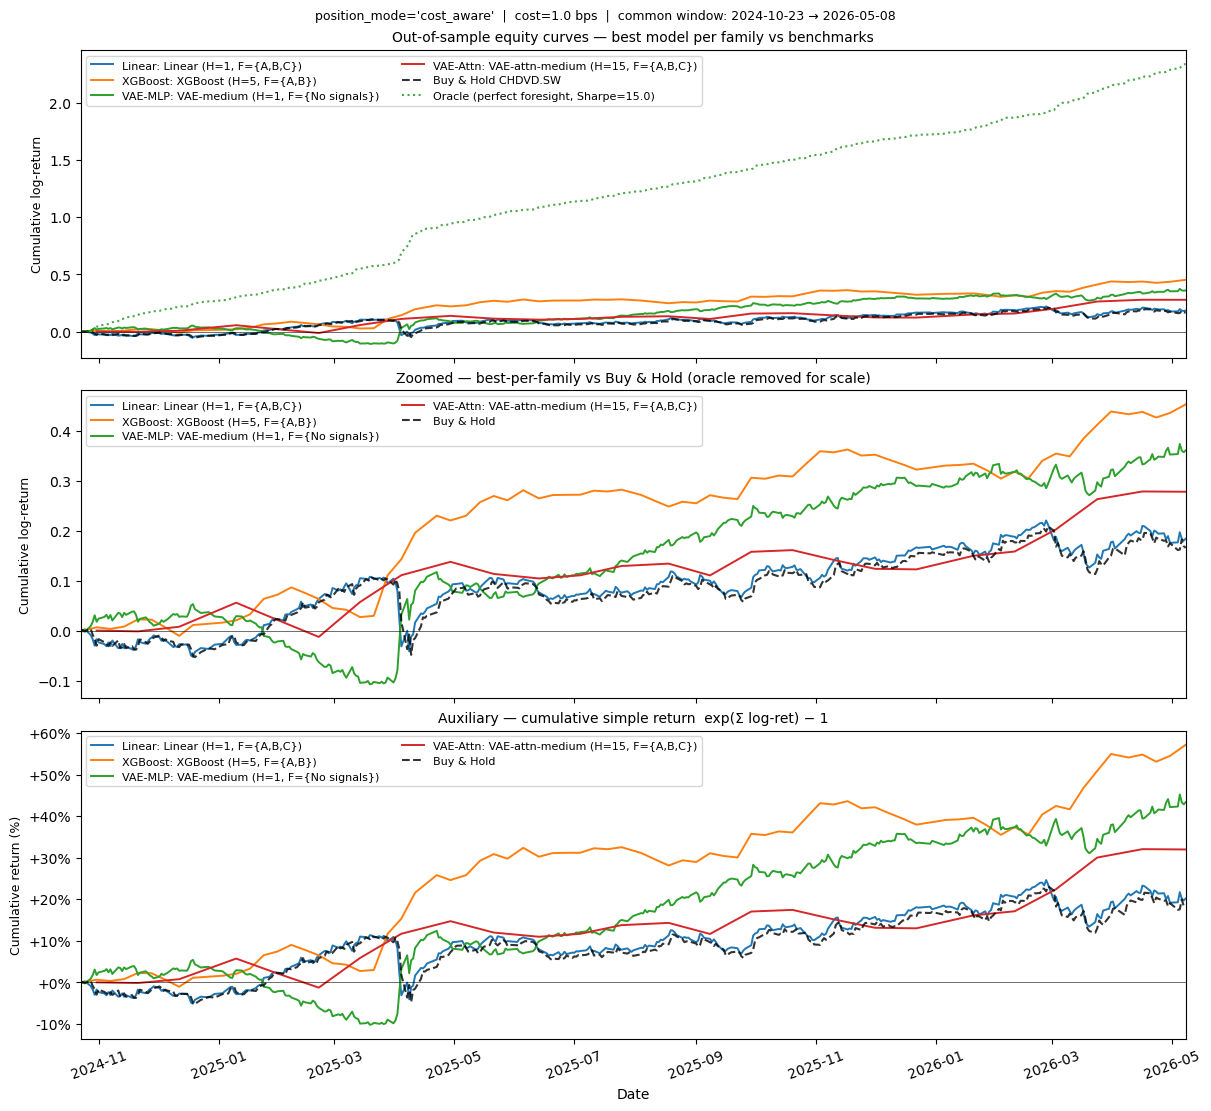

In [15]:
import matplotlib.ticker as mticker

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True, constrained_layout=True)

_bh_curve = align_curve(_daily_ret.cumsum())
_colors    = [FAMILY_COLORS.get(fam, 'grey') for fam in _best_per_family]

# Top panel: best-per-family + buy & hold + oracle
ax = axes[0]
for col, (fam, m) in zip(_colors, _best_per_family.items()):
    strat = align_curve(curves_by_model[m]['strategy'])
    ax.plot(strat.index, strat.values,
            label=f'{fam}: {model_label(m)}', linewidth=1.4, color=col)
ax.plot(_bh_curve.index, _bh_curve, 'k--', linewidth=1.5, label='Buy & Hold CHDVD.SW', alpha=0.8)
_oracle_al = align_curve(oracle_curves['strategy'])
ax.plot(_oracle_al.index, _oracle_al.values,
        color='green', linestyle=':', linewidth=1.5, alpha=0.7,
        label=f"Oracle (perfect foresight, Sharpe={oracle_stats['strat_Sharpe']:.1f})")
ax.axhline(0, color='k', linewidth=0.4)
ax.set_ylabel('Cumulative log-return', fontsize=9)
ax.set_title('Out-of-sample equity curves — best model per family vs benchmarks', fontsize=10)
ax.legend(fontsize=8, ncol=2)

# Bottom panel: zoomed (no oracle)
ax2 = axes[1]
for col, (fam, m) in zip(_colors, _best_per_family.items()):
    strat = align_curve(curves_by_model[m]['strategy'])
    ax2.plot(strat.index, strat.values,
             label=f'{fam}: {model_label(m)}', linewidth=1.4, color=col)
ax2.plot(_bh_curve.index, _bh_curve, 'k--', linewidth=1.5, label='Buy & Hold', alpha=0.8)
ax2.axhline(0, color='k', linewidth=0.4)
ax2.set_ylabel('Cumulative log-return', fontsize=9)
ax2.set_title('Zoomed — best-per-family vs Buy & Hold (oracle removed for scale)', fontsize=10)
ax2.legend(fontsize=8, ncol=2)
ax2.tick_params(axis='x', rotation=20)
ax.margins(x=0); ax2.margins(x=0)

# Auxiliary panel: cumulative simple return = exp(cum log-return) - 1 (actual % gain)
ax3 = axes[2]
for col, (fam, m) in zip(_colors, _best_per_family.items()):
    strat = align_curve(curves_by_model[m]['strategy'])
    ax3.plot(strat.index, np.exp(strat) - 1,
             label=f'{fam}: {model_label(m)}', linewidth=1.4, color=col)
ax3.plot(_bh_curve.index, np.exp(_bh_curve) - 1, 'k--', linewidth=1.5, label='Buy & Hold', alpha=0.8)
ax3.axhline(0, color='k', linewidth=0.4)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:+.0%}'))
ax3.set_ylabel('Cumulative return (%)', fontsize=9)
ax3.set_xlabel('Date')
ax3.set_title('Auxiliary — cumulative simple return  exp(\u03a3 log-ret) \u2212 1', fontsize=10)
ax3.legend(fontsize=8, ncol=2)
ax3.tick_params(axis='x', rotation=20)
ax3.margins(x=0)

fig.suptitle(f"position_mode='{_pos_mode}'  |  cost={_cost} bps  |  "
             f"common window: {COMMON_START.date()} → {COMMON_END.date()}", fontsize=9)
plt.show()


### Transaction-cost sensitivity

`COST_BPS` is charged on every unit of turnover, so high-frequency rebalancing decays fastest
as costs rise. Sweep over `COST_BPS_GRID` (0 = frictionless; 5–20 bps ≈ realistic retail
all-in cost) for the best model per family, against Buy & Hold (which pays no rebalancing cost).


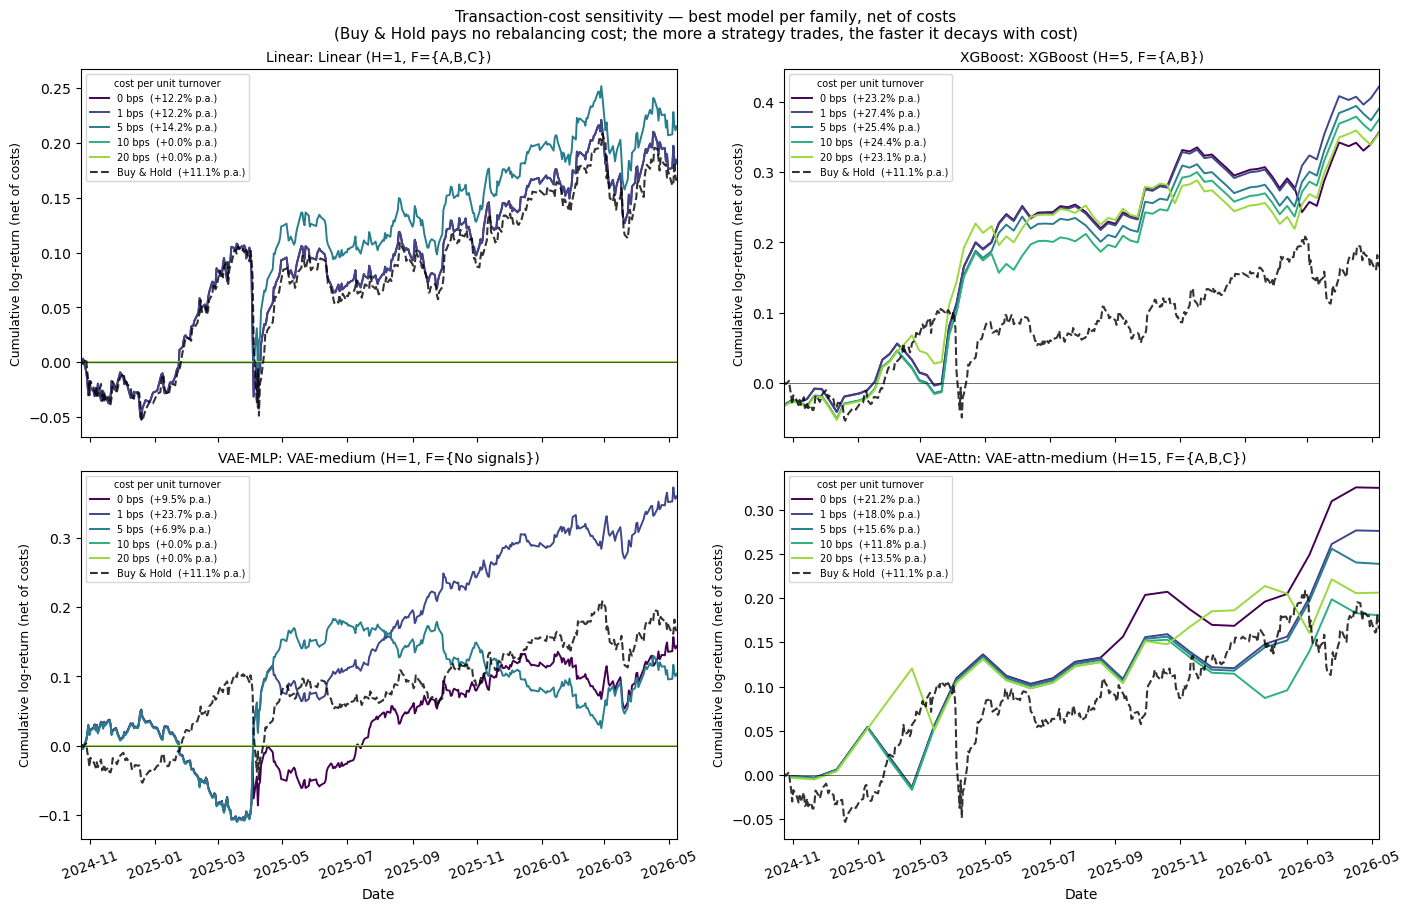

In [16]:
# ── Transaction-cost sensitivity: best model per family vs Buy & Hold ────────
from utils.metrics import annualised_return, TRADING_DAYS

_cost_colors = plt.cm.viridis(np.linspace(0.0, 0.85, len(COST_BPS_GRID)))

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, constrained_layout=True)

for ax, (fam, m) in zip(axes.ravel(), _best_per_family.items()):
    h, s = _model_meta[m]
    _sub = (pred_df[(pred_df['model'] == m) & (pred_df['horizon'] == h)
                    & (pred_df['signal_config'] == s)]
            .drop_duplicates('date', keep='last').set_index('date').sort_index()
            .loc[COMMON_START:COMMON_END])
    _pred = _sub['pred_return_raw'].values
    _real = _sub['realized_return'].values
    _periods = round(TRADING_DAYS / max(1, h))
    for c, col in zip(COST_BPS_GRID, _cost_colors):
        pnl = strategy_returns(_pred, _real, mode=_pos_mode, cost_bps=c)
        ann = annualised_return(pnl, periods=_periods)
        ax.plot(_sub.index, np.cumsum(pnl), color=col, linewidth=1.4,
                label=f'{c:g} bps  ({ann:+.1%} p.a.)')
    ax.plot(_bh_curve.index, _bh_curve, 'k--', linewidth=1.5, alpha=0.8,
            label=f'Buy & Hold  ({_bh_annret:+.1%} p.a.)')
    ax.axhline(0, color='k', linewidth=0.4)
    ax.set_title(f'{fam}: {model_label(m)}', fontsize=10)
    ax.set_ylabel('Cumulative log-return (net of costs)', fontsize=9)
    ax.legend(fontsize=7, title='cost per unit turnover', title_fontsize=7, loc='upper left')
    ax.tick_params(axis='x', rotation=20)
    ax.margins(x=0)
for ax in axes.ravel()[len(_best_per_family):]:
    ax.set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel('Date')

fig.suptitle('Transaction-cost sensitivity — best model per family, net of costs\n'
             '(Buy & Hold pays no rebalancing cost; the more a strategy trades, the faster it decays with cost)',
             fontsize=11)
plt.show()


### Signal decisions vs. cumulative strategy returns
Each model's position decision (+1 long / 0 flat) plotted as a heatmap alongside
the cumulative log-return, so you can see *when* each model is in the market
and whether that aligns with the up/down periods of the ETF.

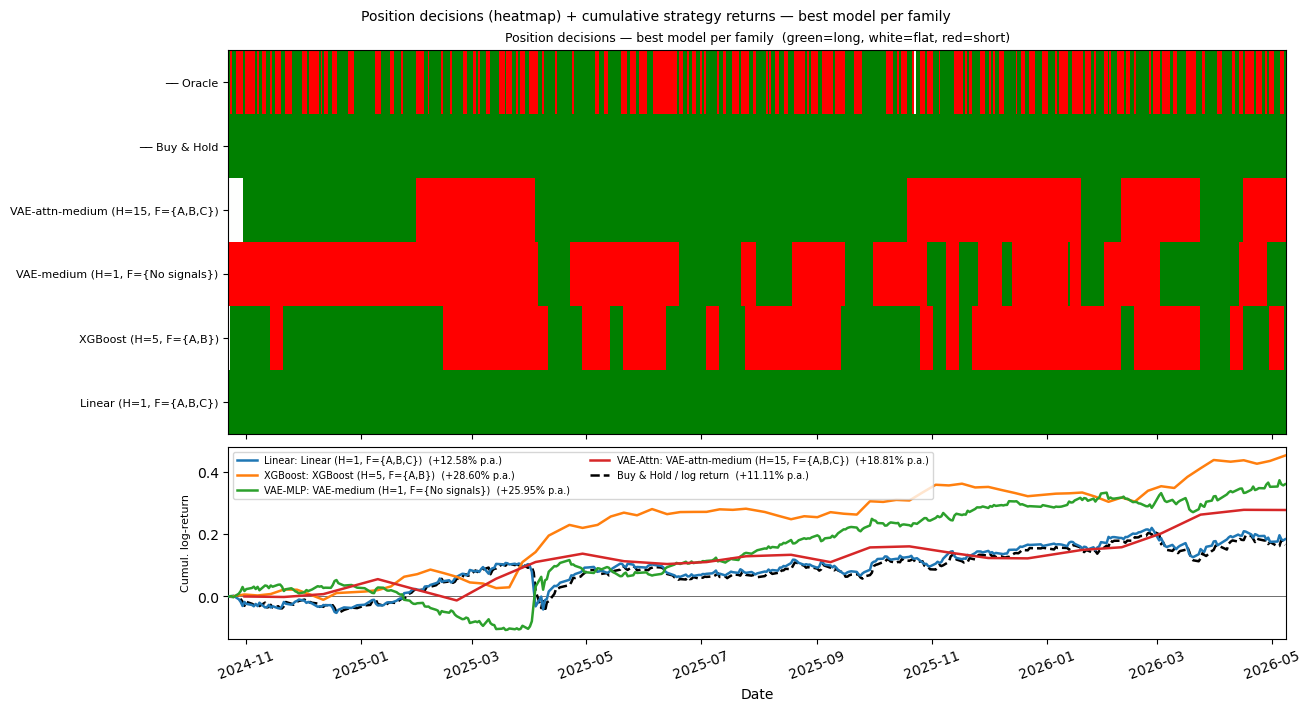

In [17]:
from utils.backtest import forecast_to_position
import matplotlib.colors as mcolors

_dates = split.dates_test[(split.dates_test >= COMMON_START) & (split.dates_test <= COMMON_END)]
_real  = pd.Series(split.inverse_y(split.y_test), index=split.dates_test).reindex(_dates).values
_bh_cumret = align_curve(_daily_ret.cumsum())

# Sign positions: -1 (short), 0 (flat), +1 (long)
_oracle_pos = np.sign(_real)
_bh_pos     = np.ones(len(_dates))

pos_matrix = {}
for m in _rep_models:
    _pred = preds_by_model[m]['test'].reindex(_dates).values
    pos_matrix[m] = forecast_to_position(_pred, mode=_pos_mode, cost_bps=_cost)
pos_matrix['── Buy & Hold'] = _bh_pos
pos_matrix['── Oracle']    = _oracle_pos

_all_names = _rep_models + ['── Buy & Hold', '── Oracle']

pos_df = pd.DataFrame(pos_matrix, index=_dates)
n_rows = len(_all_names)
fig, (ax_heat, ax_ret) = plt.subplots(
    2, 1, figsize=(13, 4 + 0.5 * n_rows), sharex=True,
    constrained_layout=True,
    gridspec_kw={'height_ratios': [n_rows, 3]},
)

# Red = -1 (short), white = 0 (flat), green = +1 (long)
_rwg = mcolors.LinearSegmentedColormap.from_list('rwg', ['red', 'white', 'green'])

pos_arr = pos_df[_all_names].values.T
ax_heat.pcolormesh(_dates, np.arange(n_rows),
                   pos_arr, cmap=_rwg, vmin=-1, vmax=1, shading='nearest')
ax_heat.set_yticks(range(n_rows))
ax_heat.set_yticklabels([model_label(n) if n in _rep_models else n for n in _all_names], fontsize=8)
ax_heat.set_title('Position decisions — best model per family  (green=long, white=flat, red=short)', fontsize=9)

# One line per model family + daily log return (= buy & hold)
_fam_colors = [FAMILY_COLORS.get(fam, 'grey') for fam in _best_per_family]
for (fam, m), col in zip(_best_per_family.items(), _fam_colors):
    strat_cum = align_curve(curves_by_model[m]['strategy'])
    ax_ret.plot(strat_cum.index, strat_cum.values,
                color=col, linewidth=1.8, zorder=5,
                label=f'{fam}: {model_label(m)}  ({float(results[m]["AnnRet_out"]):+.2%} p.a.)')
ax_ret.plot(_bh_cumret.index, _bh_cumret.values, 'k--', linewidth=1.8,
            label=f'Buy & Hold / log return  ({bench_stats["bench_AnnReturn"]:+.2%} p.a.)', zorder=4)
ax_ret.axhline(0, color='k', linewidth=0.4)
ax_ret.set_ylabel('Cumul. log-return', fontsize=8)
ax_ret.set_xlabel('Date')
ax_ret.legend(fontsize=7, ncol=2, loc='upper left')
ax_ret.tick_params(axis='x', rotation=20)
ax_ret.margins(x=0)

fig.suptitle('Position decisions (heatmap) + cumulative strategy returns — best model per family', fontsize=10)
plt.show()


## Forecast vs Ground Truth
Model predictions vs realized log-returns over representative windows from each period.
Shows whether forecasts track the direction of actual returns in-sample vs out-of-sample.

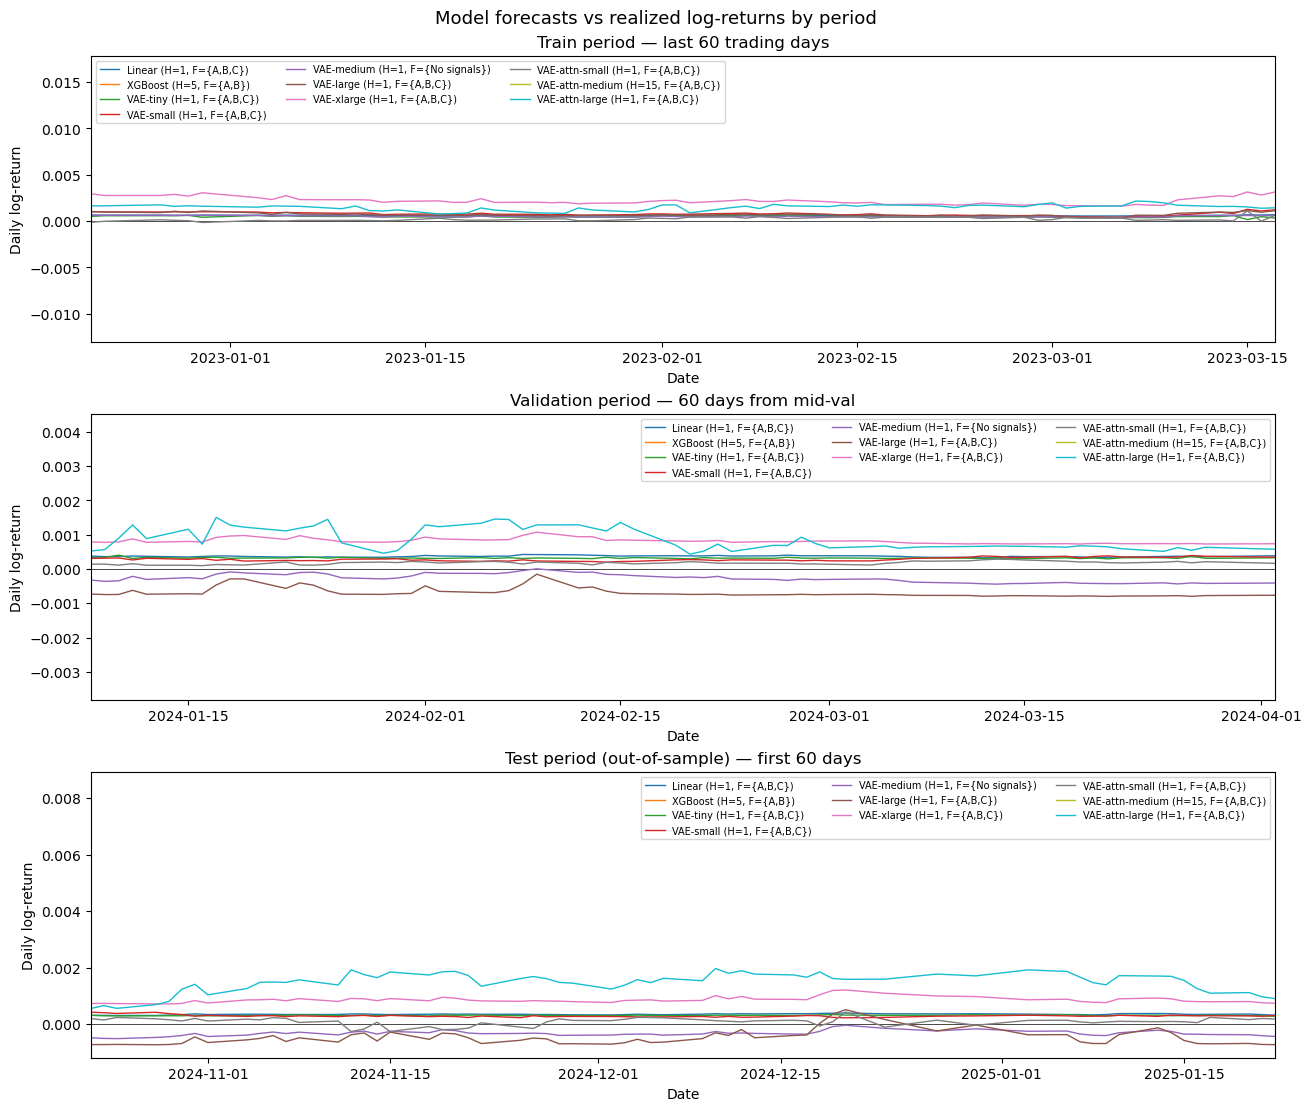

In [18]:
def forecast_comparison_plot(preds_by_model, realized_all, start_date, n_days, title, ax):
    """Plot all model forecasts vs realized for a date window.

    preds_by_model : {name: pd.Series indexed by DatetimeIndex}
    realized_all   : pd.Series of actual log-returns indexed by DatetimeIndex
    start_date     : first date of window (str or Timestamp)
    n_days         : number of trading days to display
    """
    start  = pd.Timestamp(start_date)
    window = realized_all.loc[start:].iloc[:n_days]
    dates  = window.index

    ax.axhline(0, color='black', linewidth=0.5)
    for name, preds in preds_by_model.items():
        ax.plot(dates, preds.reindex(dates), linewidth=1.0, label=name)
    ax.set_title(title)
    ax.set_ylabel('Daily log-return')
    ax.set_xlabel('Date')
    ax.legend(fontsize=7, ncol=3)
    ax.set_xlim(dates[0], dates[-1])


# Combine all predictions and realized returns across every split
realized_all = pd.Series(
    np.concatenate([split.inverse_y(split.y_train),
                    split.inverse_y(split.y_val),
                    split.inverse_y(split.y_test)]),
    index=np.concatenate([split.dates_train, split.dates_val, split.dates_test])
).sort_index()

preds_all = {
    model_label(name): pd.concat([p['train'], p['test']]).sort_index()
    for name, p in preds_by_model.items()
}

N = FORECAST_PLOT_DAYS  # trading days per panel
windows = [
    (split.dates_train[-N],                        f'Train period — last {N} trading days'),
    (split.dates_val[len(split.dates_val) // 2],   f'Validation period — {N} days from mid-val'),
    (split.dates_test[0],                          f'Test period (out-of-sample) — first {N} days'),
]

fig, axes = plt.subplots(3, 1, figsize=(13, 11), constrained_layout=True)
for ax, (start, title) in zip(axes, windows):
    forecast_comparison_plot(preds_all, realized_all, start, N, title, ax)
fig.suptitle('Model forecasts vs realized log-returns by period', fontsize=13)
plt.show()

## 6. Signal-set Ablation
Results from the §4 big-run cell. Each of 8 signal configs × 3 model types.

Hypothesis: combining complementary signal sets improves IC (A+B+C > A+B > A only).

In [19]:
# Signal × Horizon ablation — IC_out, AnnRet_out, Sharpe_out pivot per model
_abl = pd.DataFrame(ablation_rows)

for _mname in ABLATION_MODELS:
    _sub = _abl[_abl['model'] == _mname].copy()
    _sig_order = list(SIGNAL_CONFIGS.keys())
    for metric, label in [('IC_out', 'IC_out'), ('AnnRet_out', 'AnnRet (p.a.)'), ('Sharpe_out', 'Sharpe')]:
        piv = _sub.pivot_table(index='signals', columns='horizon',
                               values=metric, aggfunc='mean').round(4)
        piv = piv.reindex([s for s in _sig_order if s in piv.index])
        piv.columns = [f'h={c}d' for c in piv.columns]
        print(f"\n  {label} — {_mname}")
        display(piv.fillna('—'))



  IC_out — Linear


,h=1d,h=5d,h=15d,h=30d
signals,,,,
A only,0.0536,0.1422,0.081,0.2583
B only,0.0536,0.1422,0.081,0.2583
C only,0.0536,0.1422,0.081,0.2583
A + B,0.0536,0.1422,0.081,0.2583
A + C,0.0536,0.1422,0.081,0.2583
B + C,0.0536,0.1422,0.081,0.2583
A + B + C,0.0536,0.1422,0.081,0.2583
No signals,0.0536,0.1422,0.081,0.2583



  AnnRet (p.a.) — Linear


,h=1d,h=5d,h=15d,h=30d
signals,,,,
A only,0.1258,0.1101,0.1166,-0.0224
B only,0.1258,0.1101,0.1166,-0.0224
C only,0.1258,0.1101,0.1166,-0.0224
A + B,0.1258,0.1101,0.1166,-0.0224
A + C,0.1258,0.1101,0.1166,-0.0224
B + C,0.1258,0.1101,0.1166,-0.0224
A + B + C,0.1258,0.1101,0.1166,-0.0224
No signals,0.1258,0.1101,0.1166,-0.0224



  Sharpe — Linear


...

,h=1d,h=5d,h=15d,h=30d
signals,,,,
A only,0.1492,0.4001,0.2358,0.2221
B only,0.1250,0.3859,0.2049,0.1657
C only,0.1672,0.4090,0.2198,0.1952
A + B,0.1044,0.2273,0.3651,0.2085
A + C,0.0778,0.2435,0.3816,0.1113
B + C,0.0656,0.2252,0.2591,0.0730
A + B + C,0.1177,0.2134,0.2170,0.4107
No signals,0.1408,0.2818,-0.0365,0.2042



  AnnRet (p.a.) — VAE-medium


,h=1d,h=5d,h=15d,h=30d
signals,,,,
A only,0.1336,0.1101,0.1183,0.0998
B only,0.1265,0.1101,0.1183,0.0998
C only,0.1238,0.1101,0.1183,0.0998
A + B,0.1258,0.1254,0.1166,0.0998
A + C,0.1450,0.1366,0.1166,0.0998
B + C,0.1258,0.1672,0.1166,0.0998
A + B + C,0.1480,0.1101,0.1470,0.0998
No signals,0.2595,0.1101,0.1166,0.0998



  Sharpe — VAE-medium


,h=1d,h=5d,h=15d,h=30d
signals,,,,
A only,0.9564,0.8229,0.9684,1.3535
B only,0.9029,0.8229,0.9684,1.3535
C only,0.8834,0.8229,0.9684,1.3535
A + B,0.8979,0.9384,0.9536,1.3535
A + C,1.0350,1.0239,0.9536,1.3535
B + C,0.8979,1.2605,0.9536,1.3535
A + B + C,1.0566,0.8229,1.2215,1.3535
No signals,1.8617,0.8229,0.9536,1.3535


### Signal-set ablation — visualized
IC_out and Sharpe as heatmap (green = better) and grouped bar chart.
**Hypothesis:** combining trend (A) + mean-reversion (B) + regime (C) outperforms any single set,
because they are economically orthogonal and complement each other across market regimes.

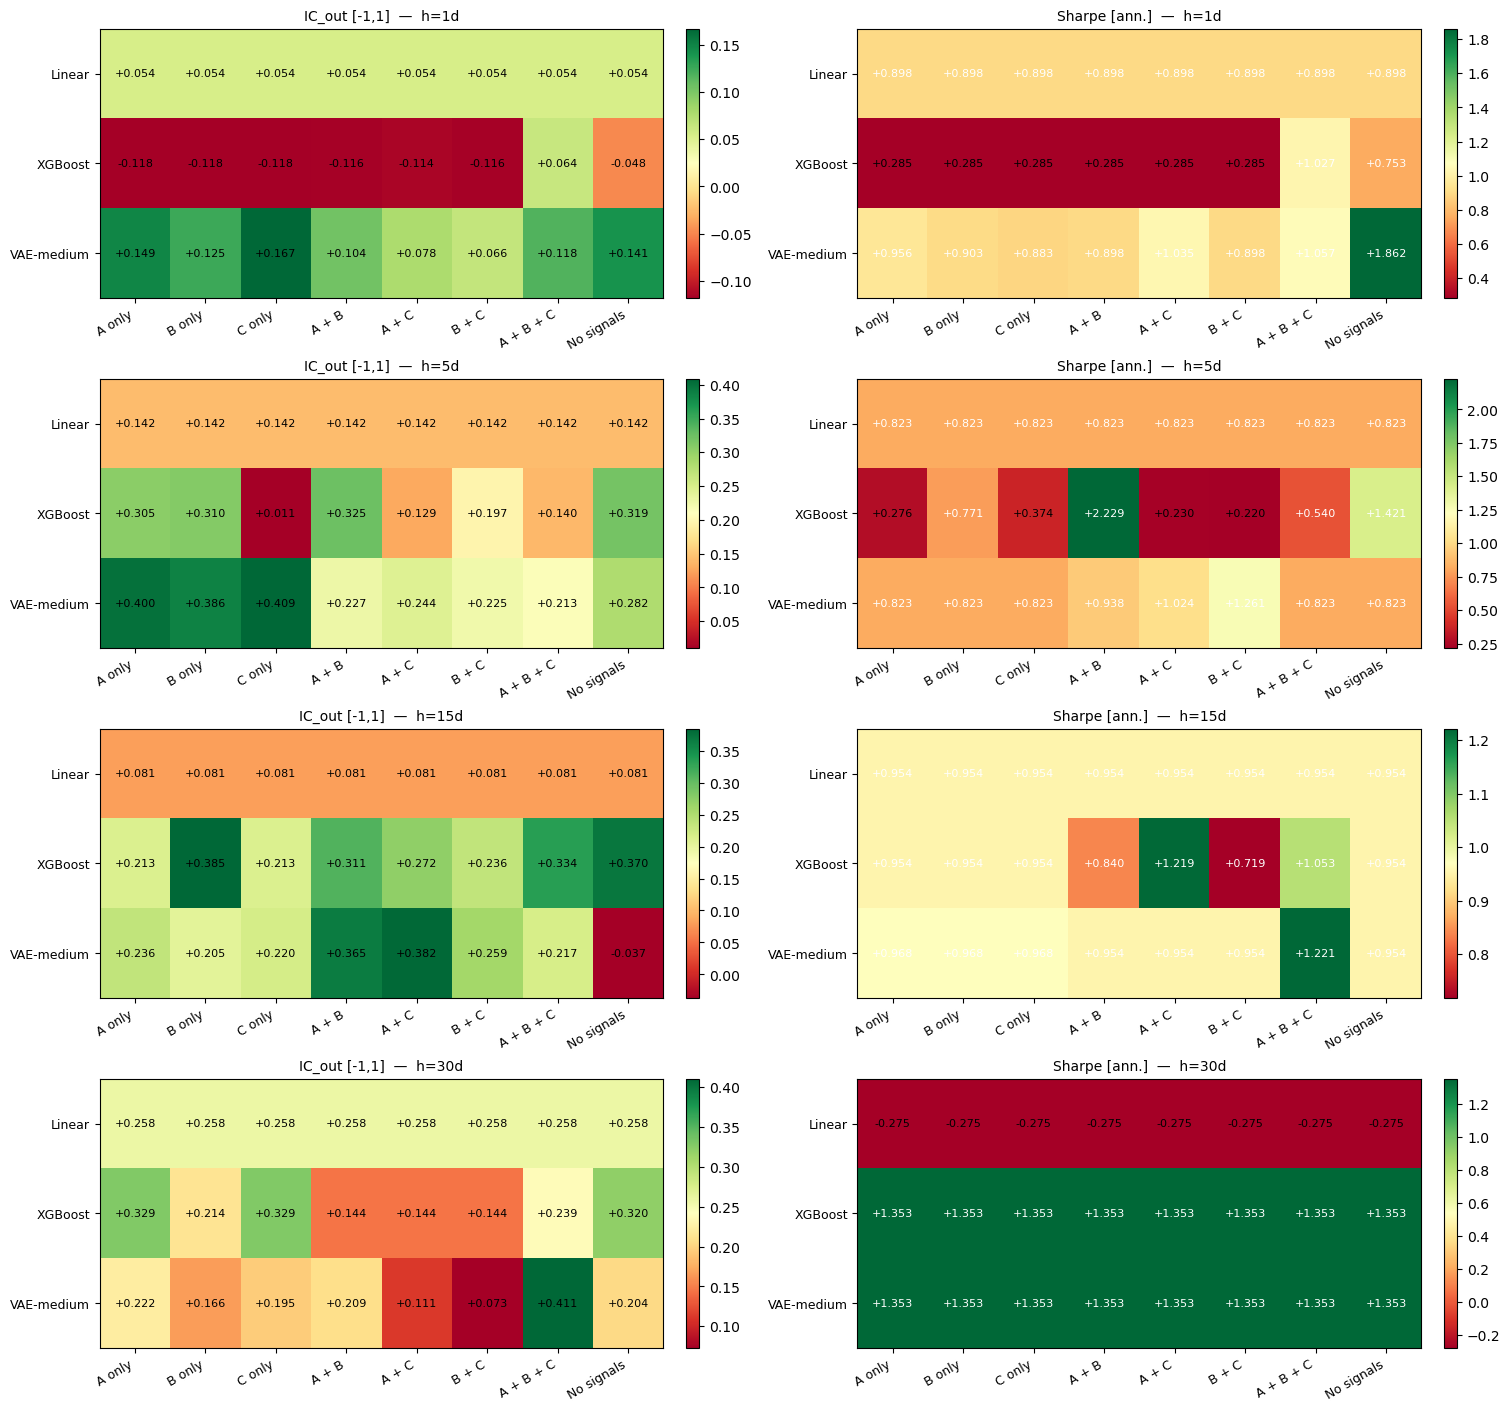

In [20]:
# ── Signal-set ablation: heatmap per horizon ────────────────────────────────
_sig_order   = list(SIGNAL_CONFIGS.keys())
_model_order = list(ABLATION_MODELS)

fig, axes = plt.subplots(len(HORIZONS), 2, figsize=(15, 3.5 * len(HORIZONS)),
                         constrained_layout=True)

for row, _h in enumerate(HORIZONS):
    _abl_h = ablation[ablation['horizon'] == _h]
    for col, (metric, label) in enumerate([('IC_out', 'IC_out [-1,1]'),
                                           ('Sharpe_out', 'Sharpe [ann.]')]):
        ax = axes[row, col]
        piv = _abl_h.pivot_table(index='model', columns='signals',
                                 values=metric, aggfunc='mean')
        piv = piv.reindex(
            index=[m for m in _model_order if m in piv.index],
            columns=[s for s in _sig_order  if s in piv.columns],
        )
        im = ax.imshow(piv.values.astype(float), cmap='RdYlGn', aspect='auto')
        ax.set_xticks(range(len(piv.columns)))
        ax.set_xticklabels(piv.columns, rotation=30, ha='right', fontsize=9)
        ax.set_yticks(range(len(piv.index)))
        ax.set_yticklabels(piv.index, fontsize=9)
        for i in range(len(piv.index)):
            for j in range(len(piv.columns)):
                v = piv.values[i, j]
                ax.text(j, i, f'{float(v):+.3f}' if str(v) != 'nan' else '—',
                        ha='center', va='center', fontsize=8,
                        color='black' if abs(float(v)) < 0.5 else 'white')
        ax.set_title(f'{label}  —  h={_h}d', fontsize=10)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.savefig('../results/ablation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### VAE capacity ablation — visualized
IC_out and Sharpe vs total parameter count (log scale) for MLP and Transformer encoders.
**Hypothesis:** KL divergence + masking + dropout limit the benefit of more capacity on this low-signal
series — expect a flat or U-shaped curve, not a monotone increase.

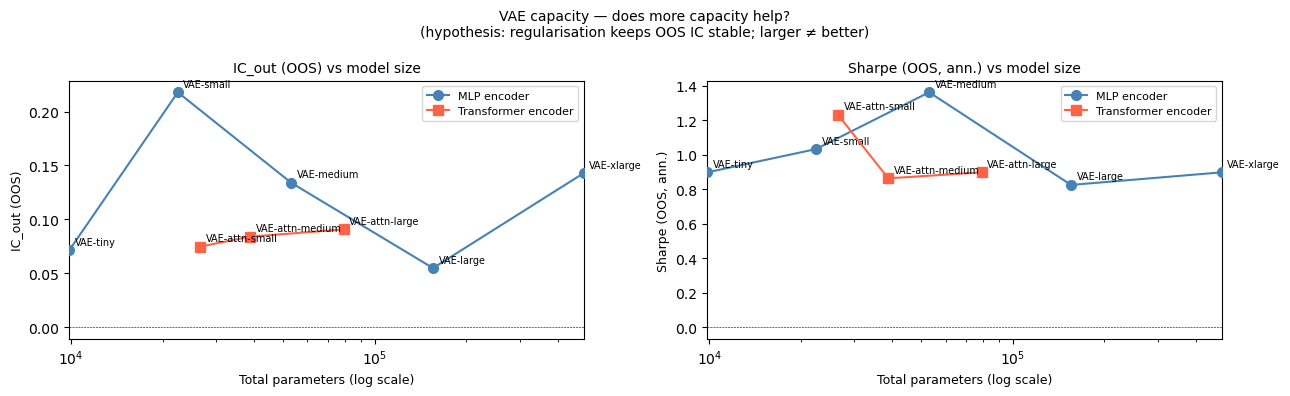

In [21]:
# ── VAE capacity curve (using vae_rows from big-run cell) ───────────────────
vae_df = pd.DataFrame(vae_rows)

if vae_df.empty:
    print("No VAE results — run §4 first.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, metric, ylabel in [
        (axes[0], 'IC_out',    'IC_out (OOS)'),
        (axes[1], 'Sharpe_out','Sharpe (OOS, ann.)'),
    ]:
        for attn_flag, label, marker, color in [
            (False, 'MLP encoder',         'o', 'steelblue'),
            (True,  'Transformer encoder', 's', 'tomato'),
        ]:
            sub = vae_df[vae_df['attention'] == attn_flag].sort_values('total_params')
            if sub.empty:
                continue
            ax.plot(sub['total_params'], sub[metric],
                    marker=marker, color=color, linewidth=1.5, markersize=7,
                    label=label, zorder=3)
            for _, r in sub.iterrows():
                ax.annotate(r['variant'], (r['total_params'], r[metric]),
                            textcoords='offset points', xytext=(4, 4), fontsize=7)
        ax.set_xscale('log')
        ax.set_xlabel('Total parameters (log scale)', fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_title(f'{ylabel} vs model size', fontsize=10)
        ax.axhline(0, color='k', linewidth=0.4, linestyle='--')
        ax.legend(fontsize=8)
    fig.suptitle('VAE capacity — does more capacity help?\n'
                 '(hypothesis: regularisation keeps OOS IC stable; larger ≠ better)',
                 fontsize=10)
    plt.tight_layout(); plt.show()

## 8. Project Summary & Takeaways

### What this project does

```
GOAL
────
Predict the next-day log-return of CHDVD.SW (iShares Swiss Dividend ETF)
and use the forecast to take a position the following day (long or flat).
We compare Masked-VAE (MLP and Transformer encoder variants) against
Lasso (OLS), XGBoost, pure signal rules, a buy-and-hold benchmark,
and an oracle (perfect foresight, theoretical upper bound).

Features include rolling statistics over CHDVD.SW and its top-10 holdings (they cover most pof the protfolio):
percentile rank, distance from max/min/mean, annualised volatility, Sharpe
ratio, and the top-5 FFT amplitudes, computed over three rolling windows
(50, 200, 365 days) plus the full expanding history. Holdings features are
compressed via PCA (≈20 components, ≥95% variance). Signal positions
({-1, 0, +1}) from three rule-based sets are appended as additional features.
See utils/features.py for the full feature catalogue.

All signal configurations (every subset of A, B, C) are tested across all
models. Model capacity is also ablated (tiny → xlarge, MLP vs. Transformer).

Training window: 2014-04-28 (CHDVD.SW inception) through today.
Test set: the most recent 15% of trading days (roughly the last year).

DATA
────
CHDVD.SW + 10 holdings · daily close · 2014–2026
yfinance auto_adjust=True  →  total returns (dividends reinvested)
Chronological split: 85% train / 15% test  (strictly no shuffling)

FEATURES  (~89 columns after PCA)
──────────────────────────────────
Benchmark rolling (44)   CHDVD_SW_*   pct-rank, vs-max/min/mean, vol, Sharpe,
                                       top-5 FFT amplitudes × 3 windows + global
Lagged returns    (20)   ret_lag_0-19  trailing 20 daily log-returns
Signal positions  (?)    pos_*         3 signal sets → {-1, 0, +1} position rules
Holdings PCA      (20)   pca_0-19      PCA of 10 holdings × 44 features each

SIGNAL SETS  (rule → position {-1, 0, +1} → ML feature + standalone baseline)
──────────────────────────────────────────────────────────────────────────────
Set A  Trend / Momentum    MA-cross 50/200 · TSMOM 12-1 · trend-strength 20
Set B  Mean-rev / Vol      RSI(14) · Bollinger z(20) · vol-ratio 20/100
Set C  Statistical / Regime  autocorr(20) · skew(60) · vol-of-vol ratio

MODELS
──────
Lasso        L1-regularised OLS · α via TimeSeriesSplit-5 CV
XGBoost      gradient-boosted trees · early stopping on val RMSE
Masked-VAE   features + target token → random masking → VAE reconstruction
             target always masked at inference → reconstruction = forecast
             variants: tiny / small / medium / large / xlarge × MLP or Attn encoder

EVALUATION  (out-of-sample, long-only, 1 bps one-way transaction cost)
───────────────────────────────────────────────────────────────────────
IC / RankIC   Pearson / Spearman correlation of forecast vs realised return
              reported both in-sample (train) and out-of-sample (test)
Sharpe        annualised; risk-free rate = 0 (Swiss near-zero rates over sample)
Buy & Hold    passive benchmark (dividends included via adjusted close)
Oracle        perfect-foresight long/short — theoretical ceiling, not tradeable
Signal rules  each pos_* backtested independently — the floor the ML must beat
```

### Results (H200 GPU run)
- The remaining questions are answered (with SUPPORTED / NOT SUPPORTED verdicts) by the auto-generated discussion cell in §9:
  - Which model has the best out-of-sample IC and Sharpe?
  - Does combining signal sets (A+B+C vs. subsets) improve IC?
  - Does extra VAE capacity help, or does regularisation keep the curve flat?
  - Do any pure-signal rules already beat buy-and-hold?



## Optuna: Joint Signal + Hyperparameter Search
Bayesian optimisation over **signal config × model hyperparameters** jointly.
Objective: validation-set IC (Pearson).  50 trials per model category.

Results auto-saved to `results/optuna_*.json`; §9 loads them alongside training runs.

| Category   | Search space |
|------------|-------------|
| Linear     | alpha ∈ [1e-6, 1] · signal config ∈ 8 options |
| XGBoost    | max_depth [3,8] · lr [0.01,0.3] · n_est [100,1000] · subsample [0.5,1] · signal config |
| VAE-MLP    | latent_dim {8,16,32} · lr [1e-4,1e-2] · beta [0.1,5] · mask_prob [0.1,0.5] · signal config |
| VAE-Attn   | same as VAE-MLP · signal config |

**Hypothesis:** joint tuning lifts validation IC well above the defaults, but part of
that gain is validation-set overfitting — the retrained winners (next section) should
give back some of the improvement on the test set while still beating the untuned defaults.

In [22]:
import optuna
import json as _json
import pathlib as _pl
optuna.logging.set_verbosity(optuna.logging.WARNING)

_RESULTS_DIR = _pl.Path('../results')
_RESULTS_DIR.mkdir(exist_ok=True)

_N_TRIALS = OPTUNA_N_TRIALS


def _get_split(trial, category):
    sig_name = trial.suggest_categorical('signal_config', list(SIGNAL_CONFIGS.keys()))
    return sig_name, make_splits(prices, returns, cfg,
                                 **SIGNAL_CONFIGS[sig_name],
                                 holding_prices=holding_prices,
                                 pca_n_components=PCA_N_COMPONENTS_ABLATION,
                                 pca_variance_threshold=PCA_VARIANCE_THRESHOLD)

def _val_ic(model, sp):
    pred_val = model.predict(sp.X_val)
    real_val = sp.y_val
    from utils.metrics import information_coefficient
    return information_coefficient(pred_val, real_val)

# ── Linear ───────────────────────────────────────────────────────────────────
def _objective_linear(trial):
    sig_name, sp = _get_split(trial, 'linear')
    from sklearn.linear_model import Lasso
    alpha = trial.suggest_float('alpha', 1e-6, 1.0, log=True)
    m = Lasso(alpha=alpha, max_iter=5000)
    m.fit(sp.X_train, sp.y_train)
    class _W:
        def predict(self, X): return m.predict(X)
    return _val_ic(_W(), sp)

study_lin = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=cfg.seed))
study_lin.optimize(_objective_linear, n_trials=_N_TRIALS, show_progress_bar=False)
print(f"Linear   best IC={study_lin.best_value:+.4f}  "
      f"alpha={study_lin.best_params.get('alpha'):.2e}  "
      f"signals={study_lin.best_params.get('signal_config')}")
_json.dump({'best_value': study_lin.best_value, 'best_params': study_lin.best_params,
            'trials': [{'value': t.value, 'params': t.params} for t in study_lin.trials]},
           open(_RESULTS_DIR / 'optuna_linear.json', 'w'), indent=2)

# ── XGBoost ──────────────────────────────────────────────────────────────────
def _objective_xgb(trial):
    sig_name, sp = _get_split(trial, 'xgb')
    from xgboost import XGBRegressor
    m = XGBRegressor(
        n_estimators    = trial.suggest_int('n_estimators', 100, 1000),
        max_depth       = trial.suggest_int('max_depth', 3, 8),
        learning_rate   = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample       = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree= 0.8,
        reg_lambda      = 1.0,
        early_stopping_rounds=30,
        objective='reg:squarederror',
        random_state=cfg.seed, n_jobs=4,
    )
    m.fit(sp.X_train, sp.y_train,
          eval_set=[(sp.X_val, sp.y_val)], verbose=False)
    class _W:
        def predict(self, X): return m.predict(X)
    return _val_ic(_W(), sp)

study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=cfg.seed))
study_xgb.optimize(_objective_xgb, n_trials=_N_TRIALS, show_progress_bar=False)
print(f"XGBoost  best IC={study_xgb.best_value:+.4f}  "
      f"depth={study_xgb.best_params.get('max_depth')}  "
      f"lr={study_xgb.best_params.get('learning_rate'):.3f}  "
      f"signals={study_xgb.best_params.get('signal_config')}")
_json.dump({'best_value': study_xgb.best_value, 'best_params': study_xgb.best_params,
            'trials': [{'value': t.value, 'params': t.params} for t in study_xgb.trials]},
           open(_RESULTS_DIR / 'optuna_xgb.json', 'w'), indent=2)

# ── VAE-MLP ──────────────────────────────────────────────────────────────────
def _objective_vae(trial, use_attention=False):
    sig_name, sp = _get_split(trial, 'vae')
    from utils.config import VAEConfig
    vcfg = VAEConfig(
        latent_dim  = trial.suggest_categorical('latent_dim', [8, 16, 32]),
        lr          = trial.suggest_float('lr', 1e-4, 1e-2, log=True),
        beta        = trial.suggest_float('beta', 0.1, 5.0),
        mask_prob   = trial.suggest_float('mask_prob', 0.1, 0.5),
        use_attention=use_attention,
        epochs=50, patience=10,
    )
    set_seed(cfg.seed)
    m = MaskedVAE(sp.n_features, vcfg, seed=cfg.seed)
    m.fit(sp.X_train, sp.y_train, sp.X_val, sp.y_val)
    return _val_ic(m, sp)

study_vae = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=cfg.seed))
study_vae.optimize(lambda t: _objective_vae(t, use_attention=False),
                   n_trials=_N_TRIALS, show_progress_bar=False)
print(f"VAE-MLP  best IC={study_vae.best_value:+.4f}  "
      f"latent={study_vae.best_params.get('latent_dim')}  "
      f"lr={study_vae.best_params.get('lr'):.2e}  "
      f"signals={study_vae.best_params.get('signal_config')}")
_json.dump({'best_value': study_vae.best_value, 'best_params': study_vae.best_params,
            'trials': [{'value': t.value, 'params': t.params} for t in study_vae.trials]},
           open(_RESULTS_DIR / 'optuna_vae_mlp.json', 'w'), indent=2)

study_vattn = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=cfg.seed))
study_vattn.optimize(lambda t: _objective_vae(t, use_attention=True),
                     n_trials=_N_TRIALS, show_progress_bar=False)
print(f"VAE-Attn best IC={study_vattn.best_value:+.4f}  "
      f"latent={study_vattn.best_params.get('latent_dim')}  "
      f"lr={study_vattn.best_params.get('lr'):.2e}  "
      f"signals={study_vattn.best_params.get('signal_config')}")
_json.dump({'best_value': study_vattn.best_value, 'best_params': study_vattn.best_params,
            'trials': [{'value': t.value, 'params': t.params} for t in study_vattn.trials]},
           open(_RESULTS_DIR / 'optuna_vae_attn.json', 'w'), indent=2)

# ── Summary table ─────────────────────────────────────────────────────────────
_optuna_results = []
for cat, study in [('Linear', study_lin), ('XGBoost', study_xgb),
                   ('VAE-MLP', study_vae), ('VAE-Attn', study_vattn)]:
    _optuna_results.append({'Category': cat,
                             'Best IC (val)': study.best_value,
                             'Best signal config': study.best_params.get('signal_config'),
                             'Best params': {k: v for k, v in study.best_params.items() if k != 'signal_config'}})
optuna_df = pd.DataFrame(_optuna_results).set_index('Category')
display(optuna_df)

  PCA on 442 holding features → 20 components  (91.6% variance explained  |  threshold=95%, max=20)
    PC 1: 33.701%  cumulative 33.701%
    PC 2: 13.695%  cumulative 47.396%
    PC 3: 11.500%  cumulative 58.896%
    PC 4: 9.078%  cumulative 67.974%
    PC 5: 4.429%  cumulative 72.403%
    PC 6: 3.503%  cumulative 75.907%
    PC 7: 3.171%  cumulative 79.077%
    PC 8: 2.310%  cumulative 81.388%
    PC 9: 1.691%  cumulative 83.079%
    PC10: 1.550%  cumulative 84.629%
    PC11: 1.226%  cumulative 85.854%
    PC12: 1.055%  cumulative 86.909%
    PC13: 0.893%  cumulative 87.802%
    PC14: 0.762%  cumulative 88.564%
    PC15: 0.669%  cumulative 89.233%
    PC16: 0.603%  cumulative 89.836%
    PC17: 0.525%  cumulative 90.360%
    PC18: 0.454%  cumulative 90.814%
    PC19: 0.401%  cumulative 91.215%
    PC20: 0.344%  cumulative 91.559%
  PCA on 442 holding features → 20 components  (91.6% variance explained  |  threshold=95%, max=20)
    PC 1: 33.701%  cumulative 33.701%
    PC 2: 13.695%  

/home/virgilio/lib/minconda3/envs/gibbon/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.586e+02, tolerance: 1.873e-01
  model = cd_fast.enet_coordinate_descent(


  PCA on 442 holding features → 20 components  (91.6% variance explained  |  threshold=95%, max=20)
    PC 1: 33.701%  cumulative 33.701%
    PC 2: 13.695%  cumulative 47.396%
    PC 3: 11.500%  cumulative 58.896%
    PC 4: 9.078%  cumulative 67.974%
    PC 5: 4.429%  cumulative 72.403%
    PC 6: 3.503%  cumulative 75.907%
    PC 7: 3.171%  cumulative 79.077%
    PC 8: 2.310%  cumulative 81.388%
    PC 9: 1.691%  cumulative 83.079%
    PC10: 1.550%  cumulative 84.629%
    PC11: 1.226%  cumulative 85.854%
    PC12: 1.055%  cumulative 86.909%
    PC13: 0.893%  cumulative 87.802%
    PC14: 0.762%  cumulative 88.564%
    PC15: 0.669%  cumulative 89.233%
    PC16: 0.603%  cumulative 89.836%
    PC17: 0.525%  cumulative 90.360%
    PC18: 0.454%  cumulative 90.814%
    PC19: 0.401%  cumulative 91.215%
    PC20: 0.344%  cumulative 91.559%
  PCA on 442 holding features → 20 components  (91.6% variance explained  |  threshold=95%, max=20)
    PC 1: 33.701%  cumulative 33.701%
    PC 2: 13.695%  

/home/virgilio/lib/minconda3/envs/gibbon/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.743e+01, tolerance: 1.873e-01
  model = cd_fast.enet_coordinate_descent(
[W 2026-06-11 13:49:21,358] Trial 5 failed with parameters: {'signal_config': 'B + C'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/virgilio/lib/minconda3/envs/gibbon/lib/python3.13/site-packages/optuna/study/_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_257957/3716317266.py", line 28, in _objective_linear
    sig_name, sp = _get_split(trial, 'linear')
                   ~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_257957/3716317266.py", line 14, in _get_split
    return sig_name, make_splits(prices, re

KeyboardInterrupt: 

## Optuna winners: test-set evaluation
Retrain each Optuna best config on **train+val** and evaluate on the **test set**
(same protocol as `run_model`: sign positions, 1 bps cost, h=1). Runs are saved to
`results/` as `<Family>-tuned`, so §9 picks them up with full test metrics —
directly comparable to the baseline runs (unlike the `Optuna-*` rows, whose IC is
validation-set IC).

The plot below compares, per family, the best baseline h=1 run (default
hyperparameters) against its Optuna-tuned version. Missing study JSONs
(e.g. `optuna_vae_attn.json` if that study was interrupted) are skipped —
re-run the Optuna cell to produce them.

In [ ]:
# Retrain each Optuna winner on train+val and evaluate on the test set via
# run_model, so the tuned models land in results/ with full test metrics and
# appear in §9. Always retrains (cheap; tuned names are not in the weight-loader map).
import json as _json
import pathlib as _pl

_RESULTS_DIR = _pl.Path('../results')

class _TunedLasso:
    """Lasso with the Optuna-selected alpha, matching the run_model interface."""
    def __init__(self, alpha):
        from sklearn.linear_model import Lasso
        self.model = Lasso(alpha=alpha, max_iter=5000)
    def fit(self, X, y, X_val=None, y_val=None, verbose=False):
        self.model.fit(X, y)
        return self
    def predict(self, X):
        return self.model.predict(X)
    def save(self, path):
        import joblib
        joblib.dump(self.model, path)

def _tuned_model(fam, bp, n_features):
    if fam == 'Linear':
        return _TunedLasso(bp['alpha'])
    if fam == 'XGBoost':
        from utils.config import XGBConfig
        return XGBoostBaseline(XGBConfig(n_estimators=bp['n_estimators'],
                                         max_depth=bp['max_depth'],
                                         learning_rate=bp['learning_rate'],
                                         subsample=bp['subsample']),
                               seed=cfg.seed)
    vcfg = VAEConfig(latent_dim=bp['latent_dim'], lr=bp['lr'], beta=bp['beta'],
                     mask_prob=bp['mask_prob'],
                     use_attention=(fam == 'VAE-Attn'), epochs=50, patience=10)
    return MaskedVAE(n_features, vcfg, seed=cfg.seed)

_OPTUNA_FILES = {'Linear': 'optuna_linear.json', 'XGBoost': 'optuna_xgb.json',
                 'VAE-MLP': 'optuna_vae_mlp.json', 'VAE-Attn': 'optuna_vae_attn.json'}

tuned_results = {}
for _fam, _fname in _OPTUNA_FILES.items():
    _path = _RESULTS_DIR / _fname
    if not _path.exists():
        print(f"  {_fam:<9} skipped — {_fname} missing (run the Optuna cell first)")
        continue
    _study = _json.loads(_path.read_text())
    _bp  = _study['best_params']
    _sig = _bp['signal_config']
    # same split settings as the Optuna objective (_get_split)
    _sp  = make_splits(prices, returns, cfg, **SIGNAL_CONFIGS[_sig],
                       holding_prices=holding_prices,
                       pca_n_components=PCA_N_COMPONENTS_FULL, pca_variance_threshold=0.PCA_VARIANCE_THRESHOLD)
    set_seed(cfg.seed)
    res_t, curves_t, preds_t = run_model(
        lambda f=_fam, b=_bp, s=_sp: _tuned_model(f, b, s.n_features),
        _sp, name=f'{_fam}-tuned', train=True, verbose=False,
        seed=cfg.seed, signals_meta=SIGNAL_CONFIGS[_sig], horizon=cfg.horizon,
    )
    tuned_results[_fam] = {'signal_config': _sig,
                           'IC_val_optuna': _study['best_value'], **res_t}
    print(f"  {_fam:<9} signals={_sig:<11} IC_val={_study['best_value']:+.4f} → "
          f"IC_out={res_t['IC_out']:+.4f}  RankIC={res_t['RankIC_out']:+.4f}  "
          f"Sharpe={res_t['Sharpe_out']:+.2f}  AnnRet={res_t['AnnRet_out']:+.2%}")

  PCA on 442 holding features → 20 components  (91.6% variance explained  |  threshold=95%, max=20)
    PC 1: 33.701%  cumulative 33.701%
    PC 2: 13.695%  cumulative 47.396%
    PC 3: 11.500%  cumulative 58.896%
    PC 4: 9.078%  cumulative 67.974%
    PC 5: 4.429%  cumulative 72.403%
    PC 6: 3.503%  cumulative 75.907%
    PC 7: 3.171%  cumulative 79.077%
    PC 8: 2.310%  cumulative 81.388%
    PC 9: 1.691%  cumulative 83.079%
    PC10: 1.550%  cumulative 84.629%
    PC11: 1.226%  cumulative 85.854%
    PC12: 1.055%  cumulative 86.909%
    PC13: 0.893%  cumulative 87.802%
    PC14: 0.762%  cumulative 88.564%
    PC15: 0.669%  cumulative 89.233%
    PC16: 0.603%  cumulative 89.836%
    PC17: 0.525%  cumulative 90.360%
    PC18: 0.454%  cumulative 90.814%
    PC19: 0.401%  cumulative 91.215%
    PC20: 0.344%  cumulative 91.559%
  Linear    signals=B only      IC_val=+0.0870 → IC_out=+0.0739  RankIC=+0.0550  Sharpe=+0.95  AnnRet=+13.28%
  PCA on 442 holding features → 20 components  

/home/virgilio/lib/minconda3/envs/gibbon/lib/python3.13/site-packages/xgboost/sklearn.py:1116: UserWarning: [13:49:31] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)


  XGBoost   signals=A + C       IC_val=+0.3040 → IC_out=+0.0547  RankIC=-0.0029  Sharpe=+0.90  AnnRet=+12.63%
  PCA on 442 holding features → 20 components  (91.6% variance explained  |  threshold=95%, max=20)
    PC 1: 33.701%  cumulative 33.701%
    PC 2: 13.695%  cumulative 47.396%
    PC 3: 11.500%  cumulative 58.896%
    PC 4: 9.078%  cumulative 67.974%
    PC 5: 4.429%  cumulative 72.403%
    PC 6: 3.503%  cumulative 75.907%
    PC 7: 3.171%  cumulative 79.077%
    PC 8: 2.310%  cumulative 81.388%
    PC 9: 1.691%  cumulative 83.079%
    PC10: 1.550%  cumulative 84.629%
    PC11: 1.226%  cumulative 85.854%
    PC12: 1.055%  cumulative 86.909%
    PC13: 0.893%  cumulative 87.802%
    PC14: 0.762%  cumulative 88.564%
    PC15: 0.669%  cumulative 89.233%
    PC16: 0.603%  cumulative 89.836%
    PC17: 0.525%  cumulative 90.360%
    PC18: 0.454%  cumulative 90.814%
    PC19: 0.401%  cumulative 91.215%
    PC20: 0.344%  cumulative 91.559%
  VAE-MLP   signals=A + B + C   IC_val=+0.1349 

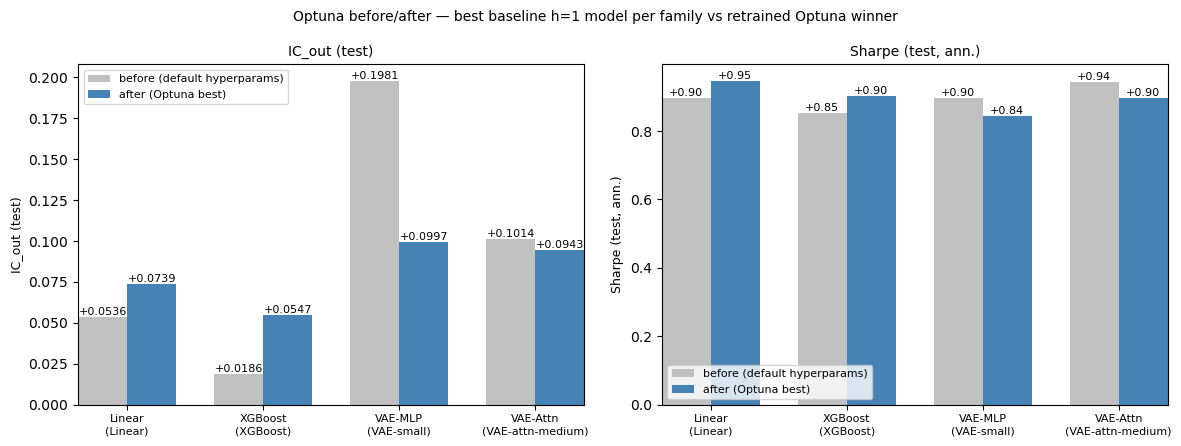

In [ ]:
# Before/after Optuna per family: the family's best baseline h=1 run
# (default hyperparameters, picked by IC_out) vs the retrained Optuna winner.
from utils.results import load_all_runs

_runs = load_all_runs()
_h1 = _runs[(_runs['source'] == 'training') & (_runs['horizon'] == 1)]
_h1 = _h1.sort_values('timestamp').groupby('model').tail(1)  # latest run per model

_ba_rows = []
for _fam, _members in MODEL_FAMILIES.items():
    _base  = _h1[_h1['model'].isin(_members)]
    _tuned = _h1[_h1['model'] == f'{_fam}-tuned']
    if _base.empty or _tuned.empty:
        print(f"  {_fam}: missing {'baseline' if _base.empty else 'tuned'} h=1 run — skipped")
        continue
    _b = _base.loc[_base['IC_out'].idxmax()]
    _t = _tuned.iloc[0]
    _ba_rows.append({'family': _fam, 'base_model': _b['model'],
                     'IC_before': _b['IC_out'],         'IC_after': _t['IC_out'],
                     'Sharpe_before': _b['Sharpe_out'], 'Sharpe_after': _t['Sharpe_out']})

before_after = pd.DataFrame(_ba_rows)

if before_after.empty:
    print("Nothing to plot — run the retrain cell above first.")
else:
    _x = np.arange(len(before_after))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for ax, _bcol, _acol, _label, _fmt in [
        (axes[0], 'IC_before',     'IC_after',     'IC_out (test)',       '{:+.4f}'),
        (axes[1], 'Sharpe_before', 'Sharpe_after', 'Sharpe (test, ann.)', '{:+.2f}'),
    ]:
        _bars_b = ax.bar(_x - 0.18, before_after[_bcol], 0.36,
                         label='before (default hyperparams)', color='silver')
        _bars_a = ax.bar(_x + 0.18, before_after[_acol], 0.36,
                         label='after (Optuna best)', color='steelblue')
        for _bars in (_bars_b, _bars_a):
            for _bar in _bars:
                _v = _bar.get_height()
                ax.annotate(_fmt.format(_v), (_bar.get_x() + _bar.get_width() / 2, _v),
                            ha='center', va='bottom' if _v >= 0 else 'top', fontsize=8)
        ax.axhline(0, color='k', linewidth=0.5)
        ax.set_xticks(_x)
        ax.set_xticklabels([f"{r.family}\n({r.base_model})" for r in before_after.itertuples()],
                           fontsize=8)
        ax.set_ylabel(_label, fontsize=9)
        ax.set_title(_label, fontsize=10)
        ax.legend(fontsize=8)
    fig.suptitle('Optuna before/after — best baseline h=1 model per family vs retrained Optuna winner',
                 fontsize=10)
    plt.tight_layout()
    plt.savefig('../results/optuna_before_after.png', dpi=150, bbox_inches='tight')
    plt.show()

## 9. Cross-run Comparison
Load every saved run from `results/` and compare models under IC, Rank-IC, and Sharpe.

Run `python compare.py` from the repo root for the same output in the terminal,
or `python compare.py --latest` to show only the most recent run per model.

In [ ]:
import sys
sys.path.insert(0, os.path.abspath('..'))
from utils.compare import compare_runs

compare_df = compare_runs(latest_only=True)

_cdf = compare_df.copy()
for col in ['IC_out', 'RankIC_out']:
    if col in _cdf.columns:
        _cdf[col] = _cdf[col].map(lambda x: f'{x:+.4f}' if pd.notna(x) else '—')
if 'Sharpe_out' in _cdf.columns:
    _cdf['Sharpe_out'] = _cdf['Sharpe_out'].map(lambda x: f'{x:+.2f}' if pd.notna(x) else '—')
if 'AnnRet_out' in _cdf.columns:
    _cdf['AnnRet_out'] = _cdf['AnnRet_out'].map(lambda x: f'{np.expm1(float(x)):+.2%}' if pd.notna(x) else '—')

_order = compare_df['AnnRet_out'].astype(float).sort_values(ascending=False).index
_cdf = _cdf.reindex(_order)

_ref = pd.DataFrame([
    {'model': '── Oracle (perfect foresight)', 'horizon': 1,
     'IC_out': '+1.0000',
     'Sharpe_out': f"{oracle_stats['strat_Sharpe']:+.2f}",
     'AnnRet_out': f"{np.expm1(oracle_stats['strat_AnnReturn']):+.2%}"},
    {'model': '── Buy & Hold', 'horizon': '—',
     'IC_out': '—',
     'Sharpe_out': f"{bench_stats['bench_Sharpe']:+.2f}",
     'AnnRet_out': f"{np.expm1(bench_stats['bench_AnnReturn']):+.2%}"},
])

cols = ['model', 'horizon', 'IC_out', 'Sharpe_out', 'AnnRet_out']
_out = pd.concat([_cdf[[c for c in cols if c in _cdf.columns]].reset_index(drop=True),
                  _ref], ignore_index=True)

pd.set_option("display.max_rows", None)
display(_out)



════════════════════════════════════════════════════════════════════════
  Model Comparison Report — 114 runs (2026-06-11 → 2026-06-11)
════════════════════════════════════════════════════════════════════════

  #   Model                    IC_in[-1,1]  IC_out[-1,1]  Rank-IC[-1,1]  Sharpe[ann]  AnnRet[%pa]
  ────────────────────────────────────────────────────────────────────────
  1   abl_h5_C_only_VAE-medium       +0.0597       +0.4164        +0.2928       +0.823      +11.01%
  2   abl_h30_A_p_B_p_C_VAE-medium       +0.1631       +0.4114        +0.5341       +1.353       +9.98%
  3   abl_h5_A_only_VAE-medium       +0.0480       +0.3971        +0.3350       +0.823      +11.01%
  4   abl_h5_B_only_VAE-medium       +0.0584       +0.3872        +0.2820       +0.823      +11.01%
  5   abl_h15_B_only_XGBoost       +0.6812       +0.3846        +0.4338       +0.954      +11.66%
  6   abl_h15_A_p_C_VAE-medium       +0.1706       +0.3824        +0.3291       +0.954      +11.66%
  7   abl_h15_

,model,horizon,IC_out,Sharpe_out,AnnRet_out
0,abl_h5_A_p_B_XGBoost,5.0,+0.3248,+1.86,+27.46%
1,abl_h5_No_signals_XGBoost,5.0,+0.3192,+1.60,+23.45%
2,VAE-medium,1.0,+0.1341,+1.50,+23.25%
3,VAE-large,1.0,+0.0841,+1.09,+15.98%
4,abl_h15_A_p_B_p_C_VAE-medium,15.0,+0.2255,+1.22,+15.83%
5,abl_h15_A_p_C_XGBoost,15.0,+0.2722,+1.22,+15.81%
6,abl_h1_A_p_B_p_C_XGBoost,1.0,+0.0636,+1.03,+15.48%
7,abl_h5_A_p_C_VAE-medium,5.0,+0.2473,+1.05,+15.10%
8,abl_h1_A_p_B_p_C_VAE-medium,1.0,+0.1156,+0.96,+14.48%
9,abl_h1_A_p_C_VAE-medium,1.0,+0.0840,+0.96,+14.41%


### Results discussion — hypotheses & verdicts (auto-generated)
Every experiment's hypothesis is re-checked against the latest saved runs each time the
notebook runs. IC measures predictive power, Sharpe the risk-adjusted strategy quality,
and the in-/out-of-sample IC gap measures overfitting.

In [ ]:
# Auto-generated discussion: each hypothesis is checked against the latest saved
# runs, so re-running §4 / Optuna keeps the verdicts in sync.
from utils.results import load_all_runs

_df = load_all_runs()
_tr = _df[_df['source'] == 'training'].copy()
_tr = _tr.sort_values('timestamp').groupby(['model', 'horizon']).tail(1)
_h1 = _tr[_tr['horizon'] == 1]
_sets = _h1[['use_set_a', 'use_set_b', 'use_set_c']].fillna(False).astype(bool)

def _verdict(ok):
    return 'SUPPORTED' if ok else 'NOT SUPPORTED'

print("═" * 78)
print("  Hypotheses vs results (latest saved runs)")
print("═" * 78)

# H1: signals add predictive power
_none_ic = _h1[~_sets.any(axis=1)]['IC_out'].mean()
_any_ic  = _h1[_sets.any(axis=1)]['IC_out'].mean()
print("\nH1 — signal positions add predictive power (mean IC_out, h=1):")
print(f"     with signals = {_any_ic:+.4f}   no signals = {_none_ic:+.4f}"
      f"   → {_verdict(_any_ic > _none_ic)}")

# H2: combining sets beats any single set
_single = {s: _h1[_sets[c] & (_sets.sum(axis=1) == 1)]['IC_out'].mean()
           for s, c in [('A', 'use_set_a'), ('B', 'use_set_b'), ('C', 'use_set_c')]}
_abc = _h1[_sets.all(axis=1)]['IC_out'].mean()
print("\nH2 — combining sets beats any single set (mean IC_out, h=1):")
print("     " + "   ".join(f"{k} only = {v:+.4f}" for k, v in _single.items())
      + f"   A+B+C = {_abc:+.4f}")
print(f"     → {_verdict(_abc > max(_single.values()))}")

# H3: extra VAE capacity does not help (regularisation dominates)
_vae_order = ['VAE-tiny', 'VAE-small', 'VAE-medium', 'VAE-large', 'VAE-xlarge']
_vae = _h1[_h1['model'].isin(_vae_order)].set_index('model')['IC_out'].reindex(_vae_order)
if _vae.notna().any():
    print("\nH3 — more VAE capacity does NOT improve IC_out (h=1, A+B+C):")
    print("     " + "   ".join(f"{m.replace('VAE-', '')} = {v:+.4f}"
                               for m, v in _vae.items() if pd.notna(v)))
    print(f"     best = {_vae.idxmax()}   → {_verdict(_vae.idxmax() != 'VAE-xlarge')}")

# H4: IC rises with horizon (multi-day returns smooth out daily noise)
_by_h = _tr.groupby('horizon')['IC_out'].mean()
print("\nH4 — IC_out increases with horizon (smoother targets):")
print("     " + "   ".join(f"h={int(h)}: {v:+.4f}" for h, v in _by_h.items()))
print(f"     → {_verdict(_by_h.idxmax() != 1)}")

# H5: Optuna tuning beats the family defaults out-of-sample
print("\nH5 — Optuna-tuned configs beat family defaults on test IC (h=1):")
for _fam, _members in MODEL_FAMILIES.items():
    _t = _h1[_h1['model'] == f'{_fam}-tuned']
    _b = _h1[_h1['model'].isin(_members)]
    if _t.empty or _b.empty:
        print(f"     {_fam:<9} — tuned run missing (run the Optuna winners cell)")
        continue
    _ti, _bi = _t['IC_out'].iloc[0], _b['IC_out'].max()
    print(f"     {_fam:<9} tuned = {_ti:+.4f}   best default = {_bi:+.4f}"
          f"   → {_verdict(_ti > _bi)}")

# IS/OOS IC gap + Sharpe vs Buy & Hold, per family (h=1)
print("\nIn-/out-of-sample IC and Sharpe per family (h=1; gap = IC_in − IC_out,")
print("large positive gap ⇒ overfitting; IC_out ≈ 0 ⇒ no real predictive power):")
for _fam, _members in MODEL_FAMILIES.items():
    _b = _h1[_h1['model'].isin(_members)].dropna(subset=['IC_out'])
    if _b.empty:
        continue
    _r = _b.loc[_b['IC_out'].idxmax()]
    print(f"     {_fam:<9} {_r['model']:<16} IC_in = {_r['IC_in']:+.4f}"
          f"   IC_out = {_r['IC_out']:+.4f}   gap = {_r['IC_in'] - _r['IC_out']:+.4f}"
          f"   Sharpe = {_r['Sharpe_out']:+.2f}  (B&H {bench_stats['bench_Sharpe']:+.2f})")
print("═" * 78)

══════════════════════════════════════════════════════════════════════════════
  Hypotheses vs results (latest saved runs)
══════════════════════════════════════════════════════════════════════════════

H1 — signal positions add predictive power (mean IC_out, h=1):
     with signals = +0.0524   no signals = +0.0355   → SUPPORTED

H2 — combining sets beats any single set (mean IC_out, h=1):
     A only = +0.0314   B only = +0.0382   C only = +0.0423   A+B+C = +0.0945
     → SUPPORTED

H3 — more VAE capacity does NOT improve IC_out (h=1, A+B+C):
     tiny = +0.0831   small = +0.1981   medium = +0.1341   large = +0.0841   xlarge = +0.1599
     best = VAE-small   → SUPPORTED

H4 — IC_out increases with horizon (smoother targets):
     h=1: +0.0511   h=5: +0.2120   h=15: +0.2190   h=30: +0.2278
     → SUPPORTED

H5 — Optuna-tuned configs beat family defaults on test IC (h=1):
     Linear    tuned = +0.0739   best default = +0.0536   → SUPPORTED
     XGBoost   tuned = +0.0547   best default 

## 10. Feature Importance
Which features does each model actually rely on?

- **Lasso** (L1 penalty): irrelevant coefficients are shrunk to exactly zero — the non-zero set reveals what the model genuinely uses.
  Blue = long-signed feature; red = contrarian (model bets against it).
- **XGBoost** (gain importance): total reduction in squared-error from splits on a given feature across all trees.
  Captures non-linear interactions that Lasso misses.

/home/virgilio/lib/minconda3/envs/gibbon/lib/python3.13/site-packages/xgboost/sklearn.py:1125: UserWarning: [13:44:56] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1509: Unknown file format: `pt`. Using UBJSON (`ubj`) as a guess.
  self.get_booster().load_model(fname)


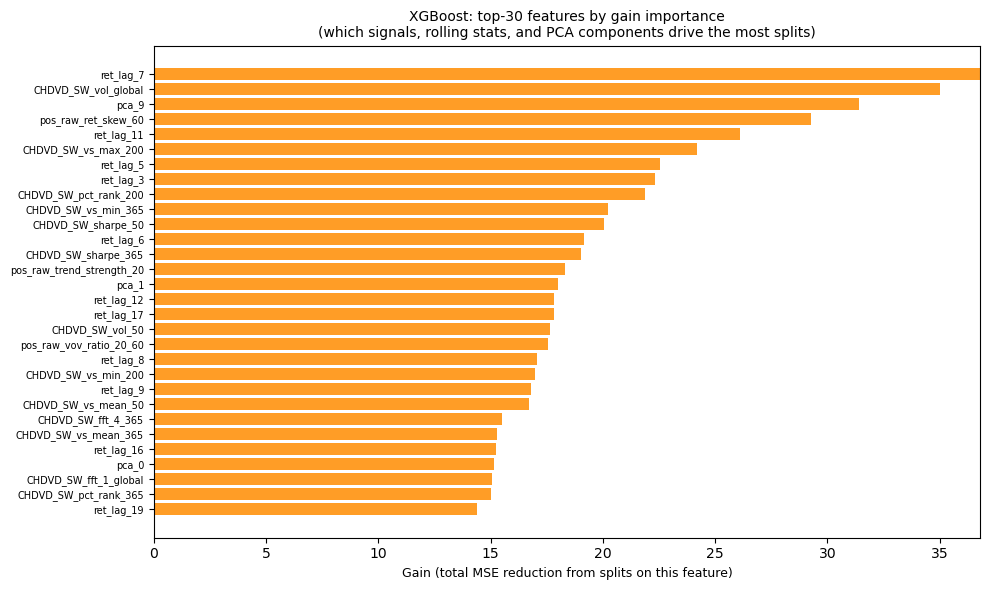

In [ ]:
# ── XGBoost: top-30 gain importance ──────────────────────────────────────────
_xgb_path = _weights_path('XGBoost', cfg.horizon)
_xgb_m    = XGBoostBaseline.load(_xgb_path) if os.path.exists(_xgb_path) else None

if _xgb_m is not None:
    _raw_imp = _xgb_m.model.get_booster().get_score(importance_type='gain')
    # XGBoost names features f0..fN when trained on numpy arrays; map to actual names
    _named = {
        split.feature_names[int(k[1:])]: v
        for k, v in _raw_imp.items()
        if k.startswith('f') and int(k[1:]) < len(split.feature_names)
    }
    _imp = pd.Series(_named).sort_values(ascending=True).tail(30)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(_imp.index, _imp.values, color='darkorange', alpha=0.85)
    ax.set_xlabel('Gain (total MSE reduction from splits on this feature)', fontsize=9)
    ax.set_title('XGBoost: top-30 features by gain importance\n'
                 '(which signals, rolling stats, and PCA components drive the most splits)', fontsize=10)
    ax.tick_params(axis='y', labelsize=7)
    plt.tight_layout(); plt.show()
else:
    print("XGBoost weights not found — run with TRAIN=True first.")

## 11. Signal Correlation & Diversity
Are the four signal sets truly complementary, or do they all say the same thing?
Low off-diagonal correlations (both raw and position-rule) justify using all four sets together
and support the economic motivation for choosing orthogonal signal families.

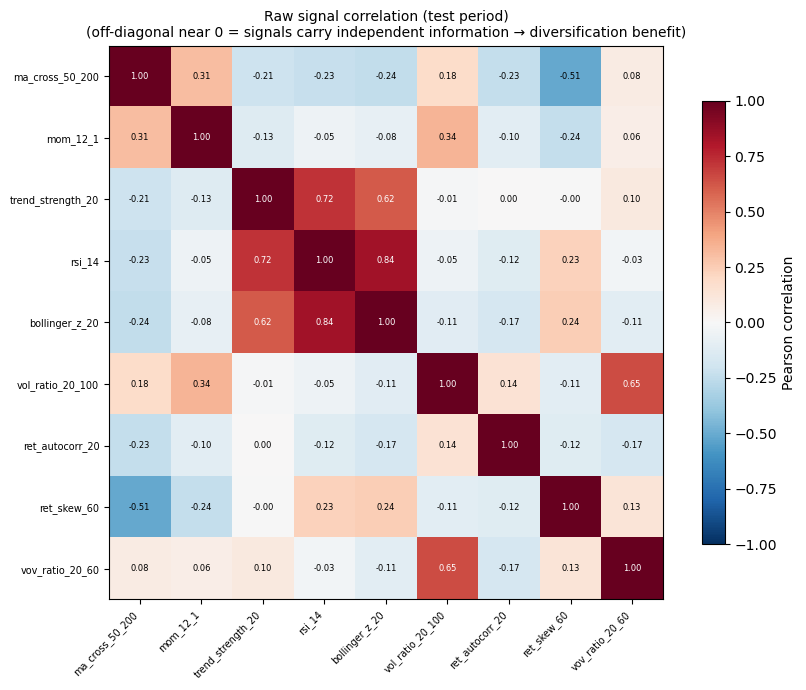

In [ ]:
# ── Signal correlation matrix (raw values, test period) ──────────────────────
_all_raw  = sig_a.join(sig_b).join(sig_c)
_corr_raw = _all_raw.reindex(split.dates_test).dropna(how='all').corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(_corr_raw.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(_corr_raw.columns)))
ax.set_xticklabels(_corr_raw.columns, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(len(_corr_raw.index)))
ax.set_yticklabels(_corr_raw.index, fontsize=7)
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson correlation')
for i in range(len(_corr_raw)):
    for j in range(len(_corr_raw.columns)):
        v = _corr_raw.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6,
                color='white' if abs(v) > 0.6 else 'black')
ax.set_title('Raw signal correlation (test period)\n'
             '(off-diagonal near 0 = signals carry independent information → diversification benefit)',
             fontsize=10)
plt.tight_layout(); plt.show()

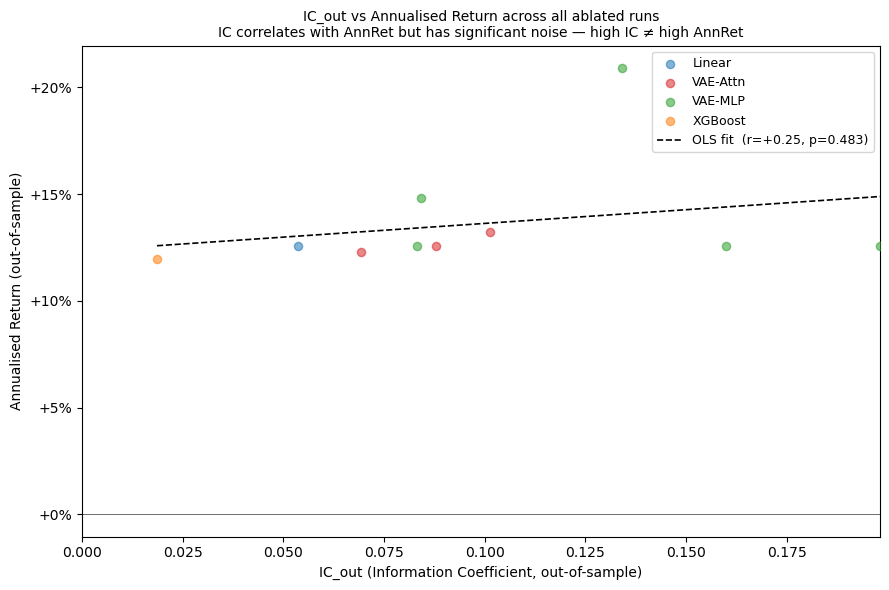

Pearson r(IC_out, AnnRet_out) = +0.252  (p=0.4832,  n=10)


In [ ]:
## IC vs Annual Return — IC correlates but is not the best indicator
import matplotlib.ticker as _mticker
from scipy.stats import pearsonr as _pearsonr

_all_run_rows = full_signal_rows + ablation_rows

_family_map = {m: fam for fam, ms in MODEL_FAMILIES.items() for m in ms}
_fam_colors = FAMILY_COLORS

_scatter_df = pd.DataFrame(_all_run_rows).dropna(subset=['IC_out', 'AnnRet_out'])
_scatter_df['family'] = _scatter_df['model'].map(lambda m: _family_map.get(m, 'Other'))

fig, ax = plt.subplots(figsize=(9, 6))

for fam, grp in _scatter_df.groupby('family'):
    ax.scatter(grp['IC_out'], grp['AnnRet_out'].astype(float),
               label=fam, color=_fam_colors.get(fam, 'grey'),
               alpha=0.55, s=35, zorder=3)

# Regression line across all points
_x = _scatter_df['IC_out'].values
_y = _scatter_df['AnnRet_out'].astype(float).values
_r, _pval = _pearsonr(_x, _y)
_m, _b = np.polyfit(_x, _y, 1)
_xline = np.linspace(_x.min(), _x.max(), 100)
ax.plot(_xline, _m * _xline + _b, 'k--', linewidth=1.2,
        label=f'OLS fit  (r={_r:+.2f}, p={_pval:.3f})')

ax.axhline(0, color='k', linewidth=0.4)
ax.axvline(0, color='k', linewidth=0.4)
ax.yaxis.set_major_formatter(_mticker.FuncFormatter(lambda v, _: f'{v:+.0%}'))
ax.set_xlabel('IC_out (Information Coefficient, out-of-sample)', fontsize=10)
ax.set_ylabel('Annualised Return (out-of-sample)', fontsize=10)
ax.set_title('IC_out vs Annualised Return across all ablated runs\n'
             'IC correlates with AnnRet but has significant noise — high IC ≠ high AnnRet',
             fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../results/ic_vs_annret.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Pearson r(IC_out, AnnRet_out) = {_r:+.3f}  (p={_pval:.4f},  n={len(_scatter_df)})")


## 12. Signal groups vs models — incremental value and behaviour

Why each group exists (economic motivation, one-liner):
- **Set A — Trend / Momentum** (`ma_cross_50_200`, `mom_12_1`, `trend_20`): returns drift; ride the persistent direction.
- **Set B — Mean-reversion / Volatility** (`rsi_14`, `bollinger_z`, `vol_regime`): stretched moves snap back; elevated short-term vol is a risk-off flag.
- **Set C — Statistical / Regime** (`autocorr_20`, `skew_60`, `vov_stable`): the shape of the return distribution tells which regime we are in (momentum vs reversal, calm vs unstable).

Three views (test period, h=1, sign positions, 1 bps cost):
1. **Per group** — each ablation model with vs without that group alone, the group's own majority-vote strategy, and the raw rule positions with the grouped behaviour.
2. **Gradual stacking** — No signals → +A → +A+B → +A+B+C, per model.
3. **All together** — top model per family vs the three group behaviours, with everyone's position decisions.

NameError: name 'pred_df' is not defined

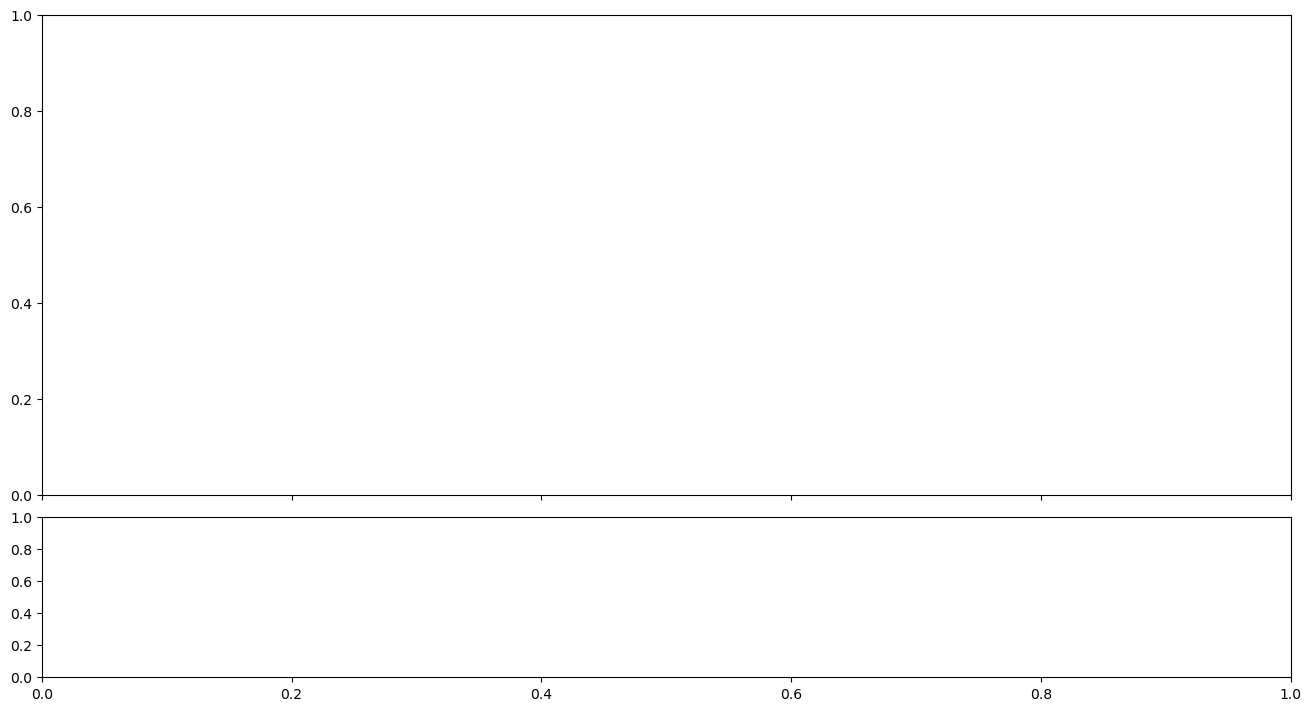

In [ ]:
# ── Per signal group: models with vs without the group + the group's own behaviour ──
# Uses pred_df (cell §4) and sig_pos (§ signal baselines); h=1, sign positions, 1 bps.
import matplotlib.colors as mcolors

_GROUPS = {
    'A': dict(cfg='A only',
              rules=['pos_ma_cross', 'pos_mom_12_1', 'pos_trend_20'],
              why='Trend / Momentum — returns drift, so follow the persistent direction'),
    'B': dict(cfg='B only',
              rules=['pos_rsi', 'pos_bollinger', 'pos_vol_regime'],
              why='Mean-reversion / Volatility — stretched moves snap back; high vol = risk-off'),
    'C': dict(cfg='C only',
              rules=['pos_autocorr', 'pos_skew', 'pos_vov_stable'],
              why='Statistical / Regime — autocorr, skew, vol-of-vol flag the return regime'),
}
_MODEL_COLORS = {'Linear': 'tab:blue', 'XGBoost': 'tab:orange', 'VAE-medium': 'tab:green'}
_rwg = mcolors.LinearSegmentedColormap.from_list('rwg', ['red', 'white', 'green'])

def _model_curve(model, sig_cfg, h=1):
    """Equity curve of a saved run rebuilt from pred_df (None if combo missing)."""
    sub = pred_df[(pred_df['model'] == model) &
                  (pred_df['signal_config'] == sig_cfg) &
                  (pred_df['horizon'] == h)].sort_values('date')
    if sub.empty:
        return None
    curves, _ = backtest_table(sub['pred_return_raw'].values,
                               sub['realized_return'].values,
                               pd.DatetimeIndex(sub['date']),
                               mode='sign', cost_bps=1.0, horizon=h)
    return curves['strategy']

def _group_majority(rules):
    """Long-only majority vote over a group's rules (same scheme as §signal baselines)."""
    pos = sig_pos[rules].reindex(_daily_dates).fillna(0)
    return np.where((pos > 0).mean(axis=1) > 0.5, 1.0, 0.0)

for _g, _spec in _GROUPS.items():
    fig, (ax_eq, ax_pos) = plt.subplots(
        2, 1, figsize=(13, 7), sharex=True, constrained_layout=True,
        gridspec_kw={'height_ratios': [3, 1]})

    # equity: each ablation model without (dotted) vs with the group only (solid)
    for _m, _c in _MODEL_COLORS.items():
        for _cfg_name, _ls, _lw in [('No signals', ':', 1.2), (_spec['cfg'], '-', 1.8)]:
            _curve = _model_curve(_m, _cfg_name)
            if _curve is not None:
                ax_eq.plot(_curve.index, _curve.values, color=_c, linestyle=_ls,
                           linewidth=_lw, label=f'{_m} — {_cfg_name}')

    # the group's own majority-vote strategy + Buy & Hold
    _maj = _group_majority(_spec['rules'])
    _maj_curves, _maj_bt = backtest_table(_maj, _daily_arr, _daily_dates,
                                          mode='sign', cost_bps=1.0)
    ax_eq.plot(_maj_curves.index, _maj_curves['strategy'], color='grey', linewidth=2.2,
               linestyle='--',
               label=f"Set {_g} majority vote (Sharpe={_maj_bt['strat_Sharpe']:+.2f})")
    ax_eq.plot(_daily_dates, _daily_ret.cumsum().values, 'k--', linewidth=1.5,
               label='Buy & Hold')
    ax_eq.axhline(0, color='k', linewidth=0.4)
    ax_eq.set_ylabel('Cumulative log-return', fontsize=9)
    ax_eq.set_title(f"Set {_g}: {_spec['why']}\n"
                    f"models without signals (dotted) vs with Set {_g} only (solid) — "
                    f"test period, h=1", fontsize=10)
    ax_eq.legend(fontsize=7, ncol=2, loc='upper left')

    # raw rule positions + grouped (majority) behaviour
    _pos = sig_pos[_spec['rules']].reindex(_daily_dates).fillna(0)
    _pos[f'Set {_g} majority'] = _maj
    ax_pos.pcolormesh(_daily_dates, np.arange(len(_pos.columns)), _pos.values.T,
                      cmap=_rwg, vmin=-1, vmax=1, shading='nearest')
    ax_pos.set_yticks(range(len(_pos.columns)))
    ax_pos.set_yticklabels(_pos.columns, fontsize=8)
    ax_pos.set_title(f'Set {_g} raw rule positions + group majority  '
                     '(green=long, white=flat, red=short)', fontsize=9)
    ax_pos.tick_params(axis='x', rotation=20)
    plt.show()

In [ ]:
# ── Gradual signal stacking: No signals → +A → +B → +C  (h=1, per ablation model) ──
_CHAIN        = ['No signals', 'A only', 'A + B', 'A + B + C']
_CHAIN_COLORS = ['silver', 'tab:blue', 'tab:purple', 'tab:red']

fig, axes = plt.subplots(1, len(_MODEL_COLORS), figsize=(15, 4.5), sharey=True,
                         constrained_layout=True)
for ax, _m in zip(axes, _MODEL_COLORS):
    for _cfg_name, _c in zip(_CHAIN, _CHAIN_COLORS):
        _curve = _model_curve(_m, _cfg_name)
        if _curve is not None:
            ax.plot(_curve.index, _curve.values, color=_c, linewidth=1.6, label=_cfg_name)
    ax.plot(_daily_dates, _daily_ret.cumsum().values, 'k--', linewidth=1.4, label='Buy & Hold')
    ax.axhline(0, color='k', linewidth=0.4)
    ax.set_title(_m, fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=7)
axes[0].set_ylabel('Cumulative log-return', fontsize=9)
fig.suptitle('Gradually adding signal groups (h=1): '
             'trend (A) → +mean-reversion (B) → +regime (C)', fontsize=10)
plt.show()

In [ ]:
# ── All together: top model per family vs each signal group's behaviour ──
_fam_top_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

fig, (ax_eq, ax_pos) = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                                    constrained_layout=True,
                                    gridspec_kw={'height_ratios': [3, 1.6]})

# group behaviours (dashed) ...
_pos_rows = {}
for _g, _spec in _GROUPS.items():
    _maj = _group_majority(_spec['rules'])
    _pos_rows[f'Set {_g} majority'] = _maj
    _c_df, _bt = backtest_table(_maj, _daily_arr, _daily_dates, mode='sign', cost_bps=1.0)
    ax_eq.plot(_c_df.index, _c_df['strategy'], linewidth=1.4, linestyle='--', alpha=0.8,
               label=f"Set {_g} majority ({_bt['strat_AnnReturn']:+.1%} p.a.)")

# ... vs top model per family (solid, each at its best run)
for _c, (_fam, _m) in zip(_fam_top_colors, _best_per_family.items()):
    _strat = curves_by_model[_m]['strategy']
    ax_eq.plot(_strat.index, _strat.values, color=_c, linewidth=2.0, zorder=5,
               label=f"{_fam}: {_m} ({float(results[_m]['AnnRet_out']):+.1%} p.a.)")
ax_eq.plot(_daily_dates, _daily_ret.cumsum().values, 'k--', linewidth=1.6,
           label='Buy & Hold', zorder=4)
ax_eq.axhline(0, color='k', linewidth=0.4)
ax_eq.set_ylabel('Cumulative log-return', fontsize=9)
ax_eq.set_title('Top model per family (solid) vs per-group signal behaviour (dashed) — '
                'test period', fontsize=10)
ax_eq.legend(fontsize=7, ncol=2, loc='upper left')

# positions: group majorities (top rows) + top-model decisions
for _fam, _m in _best_per_family.items():
    _pred = preds_by_model[_m]['test'].reindex(_daily_dates).values
    _pos_rows[f'{_fam}: {_m}'] = np.nan_to_num(forecast_to_position(_pred, mode='sign'))
_pos_df = pd.DataFrame(_pos_rows, index=_daily_dates)
ax_pos.pcolormesh(_daily_dates, np.arange(len(_pos_df.columns)), _pos_df.values.T,
                  cmap=_rwg, vmin=-1, vmax=1, shading='nearest')
ax_pos.set_yticks(range(len(_pos_df.columns)))
ax_pos.set_yticklabels(_pos_df.columns, fontsize=8)
ax_pos.set_title('Positions: group majorities + top model per family  '
                 '(green=long, white=flat, red=short)', fontsize=9)
ax_pos.tick_params(axis='x', rotation=20)
plt.savefig('../results/signal_groups_vs_models.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Cost comparison — best models vs top signal rule vs Buy & Hold

One panel per `COST_BPS_GRID` level (0 = gross, 5–20 bps ≈ realistic retail costs).
Each panel shows the best model per family and the best pure-signal rule (selected by gross
AnnRet on the common window), all net of that panel's cost. Model positions follow the
default **cost-aware** rule (`POSITION_MODE`), so the no-trade band widens with each panel's cost. Buy & Hold never rebalances, so it
is gross in every panel. This shows directly which strategies survive realistic frictions.


In [ ]:
# ── Cost comparison: best model per family vs top signal rule vs B&H ─────────
from utils.metrics import annualised_return, TRADING_DAYS

_dr = _daily_ret.loc[COMMON_START:COMMON_END]

# Candidate signal strategies (positions on the common window) + majority vote
_sig_pos_all = sig_pos.reindex(_dr.index).fillna(0)
_cand_pos = {col: _sig_pos_all[col].values for col in _sig_pos_all.columns}
_cand_pos['Combined (majority vote)'] = np.sign(_sig_pos_all.mean(axis=1)).values

# Top signal rule = highest gross AnnRet on the common window
_top_rule = max(_cand_pos, key=lambda k: annualised_return(_cand_pos[k] * _dr.values))
print(f"Top signal rule (by gross AnnRet, common window): {_top_rule}")

# Family-best model predictions, clipped to the common window
_model_data = {}
for fam, m in _best_per_family.items():
    h, s = _model_meta[m]
    _sub = (pred_df[(pred_df['model'] == m) & (pred_df['horizon'] == h)
                    & (pred_df['signal_config'] == s)]
            .drop_duplicates('date', keep='last').set_index('date').sort_index()
            .loc[COMMON_START:COMMON_END])
    _model_data[fam] = (m, _sub['pred_return_raw'].values,
                        _sub['realized_return'].values, _sub.index,
                        round(TRADING_DAYS / max(1, h)))

fig, axes = plt.subplots(len(COST_BPS_GRID), 1, figsize=(13, 3.2 * len(COST_BPS_GRID)),
                         sharex=True, constrained_layout=True)

for ax, c in zip(axes, COST_BPS_GRID):
    for fam, (m, _pred, _real, _idx, _periods) in _model_data.items():
        pnl = strategy_returns(_pred, _real, mode=_pos_mode, cost_bps=c)
        ax.plot(_idx, np.cumsum(pnl), color=FAMILY_COLORS.get(fam, 'grey'), linewidth=1.5,
                label=f'{fam}: {model_label(m)}  ({annualised_return(pnl, periods=_periods):+.1%} p.a.)')
    sig_pnl = strategy_returns(_cand_pos[_top_rule], _dr.values, mode='sign', cost_bps=c)
    ax.plot(_dr.index, np.cumsum(sig_pnl), color='darkviolet', linewidth=1.8, linestyle='-.',
            label=f'Top signal: {_top_rule}  ({annualised_return(sig_pnl):+.1%} p.a.)')
    ax.plot(_dr.index, _dr.cumsum().values, 'k--', linewidth=1.6,
            label=f'Buy & Hold (gross, {annualised_return(_dr.values):+.1%} p.a.)')
    ax.axhline(0, color='k', linewidth=0.4)
    ax.set_title(f'cost = {c:g} bps per unit turnover', fontsize=10)
    ax.set_ylabel('Cumulative log-return', fontsize=9)
    ax.legend(fontsize=7, ncol=2, loc='upper left')
axes[-1].set_xlabel('Date')
axes[-1].tick_params(axis='x', rotation=20)

fig.suptitle('Cost sensitivity — best model per family vs top signal rule vs Buy & Hold\n'
             'one panel per cost level; strategies net of that cost, B&H always gross', fontsize=11)
plt.show()


## 14. Cost-aware strategy — hold when the edge is smaller than the cost

The naive sign rule trades on **every** sign flip of the forecast, however tiny, and pays
`COST_BPS` per unit of turnover each time. The **cost-aware** rule adapts the strategy to the
cost level: it switches to `sign(forecast)` **only when the expected gain of switching exceeds
its cost**, i.e. when `|forecast| > COST_BPS / 10⁴`; otherwise it **holds the previous
position** (it does not go flat — it simply doesn't trade). At 0 bps both rules are identical
by construction.

Below: one panel per cost level. **Solid = cost-aware, faint = naive** (same colour per model
family), Buy & Hold in black dashed (gross, never rebalances). Legends report annualised
returns of both variants, net of that panel's cost.


In [ ]:
# ── Naive vs cost-aware positions for the family-best models, per cost level ─
# Reuses _model_data / _dr from section 13 (run that cell first).
from utils.backtest import cost_aware_positions
from utils.metrics import annualised_return

fig, axes = plt.subplots(len(COST_BPS_GRID), 1, figsize=(13, 3.2 * len(COST_BPS_GRID)),
                         sharex=True, constrained_layout=True)

for ax, c in zip(axes, COST_BPS_GRID):
    for fam, (m, _pred, _real, _idx, _periods) in _model_data.items():
        col = FAMILY_COLORS.get(fam, 'grey')
        pnl_naive = strategy_returns(_pred, _real, mode='sign', cost_bps=c)
        pos_ca    = cost_aware_positions(_pred, cost_bps=c)
        pnl_ca    = strategy_returns(pos_ca, _real, mode='sign', cost_bps=c)
        ann_n, ann_c = (annualised_return(p, periods=_periods) for p in (pnl_naive, pnl_ca))
        ax.plot(_idx, np.cumsum(pnl_naive), color=col, linewidth=1.0, alpha=0.35)
        ax.plot(_idx, np.cumsum(pnl_ca), color=col, linewidth=1.7,
                label=f'{fam}: {model_label(m)}  (cost-aware {ann_c:+.1%} | naive {ann_n:+.1%} p.a.)')
    ax.plot(_dr.index, _dr.cumsum().values, 'k--', linewidth=1.6,
            label=f'Buy & Hold (gross, {annualised_return(_dr.values):+.1%} p.a.)')
    ax.axhline(0, color='k', linewidth=0.4)
    ax.set_title(f'cost = {c:g} bps  —  no-trade band: hold unless |forecast| > {c/1e4:.4%}', fontsize=10)
    ax.set_ylabel('Cumulative log-return', fontsize=9)
    ax.legend(fontsize=7, ncol=2, loc='upper left')
axes[-1].set_xlabel('Date')
axes[-1].tick_params(axis='x', rotation=20)

fig.suptitle('Cost-aware vs naive sign strategy — best model per family\n'
             'solid = cost-aware (trades only when the edge beats the cost, holds otherwise)  |  '
             'faint = naive sign rule (always trades)  |  both net of the panel cost', fontsize=11)
plt.show()
